**Import Libraries**

In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, isnan, count, trim, lower, desc, hour, dayofmonth, dayofweek, month, year, to_timestamp
from pyspark.sql.types import (DoubleType, FloatType, IntegerType, LongType, ShortType, ByteType, StringType, NumericType)
from pyspark.ml.feature import Imputer
from pyspark.sql.window import Window

warnings.filterwarnings('ignore')

**Create Spark Session**

In [2]:
spark = (
    SparkSession.builder \
    .appName("SmartCity_EDA") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark Session Created Successfully")

Spark Session Created Successfully


**Output Directory**

In [3]:
CLEAN_DIR = 'clean_data'
os.makedirs(CLEAN_DIR, exist_ok=True)

print(f"Clean data will be saved to → {CLEAN_DIR}/")

Clean data will be saved to → clean_data/


**Shared Helper Functions**

In [4]:
# Helper function to check if a field is numeric
def is_numeric(field):
    return isinstance(field.dataType, NumericType)

In [5]:
# Helper function to check missing values in a DataFrame
_NULL_STRINGS = {"", "null", "None", "nan", "NaN", "NULL", "NA", "N/A"}
def check_missing_values(df, label=""):
    """
    Show per-column count of SQL Nulls + float NaN values.
    For numeric cols : counts isNull() | isnan()
    For non-numeric cols : counts isNull() only
    """
    float_cols = {
        f.name for f in df.schema.fields
        if isinstance(f.dataType, (DoubleType, FloatType))
    }

    # String columns need the broadest check
    string_cols = {
        f.name for f in df.schema.fields
        if str(f.dataType) == "StringType()"
    }

    exprs = []
    for c in df.columns:
        if c in float_cols:
            exprs.append(
                count(when(col(c).isNull() | isnan(col(c)), c)).alias(c)
            )
        elif c in string_cols:
            is_missing = col(c).isNull()
            for null_str in _NULL_STRINGS:
                is_missing = is_missing | (lower(trim(col(c))) == null_str.lower())
            exprs.append(count(when(is_missing, c)).alias(c))
        else:
            exprs.append(
                count(when(col(c).isNull(), c)).alias(c)
            )
    print(f"Missing values {label}: ")
    df.select(exprs).show(truncate=False)

In [6]:
# Helper function to check if a column is null-like (SQL NULL or any string that represents missing)
def is_null_like(c):
    """
    Returns a PySpark Column expression that is True when the value is:
      - SQL NULL
      - Any string that represents missing: "", "null", "None", "nan", etc.
    This is needed because:
      - fillna() catches SQL NULL only
      - PySpark CSV reader may read empty cells as "" (not NULL)
      - Python str(None)="None" and str(float('nan'))="nan" become literal strings
    """
    condition = col(c).isNull()
    for s in _NULL_STRINGS:
        condition = condition | (lower(trim(col(c))) == s.lower())
    return condition

In [7]:
# Helper function to count outliers
def outlier_counts(df, features):
    for col_name in features:
        Q1 = df.approxQuantile(col_name, [0.25], 0.01)[0]
        Q3 = df.approxQuantile(col_name, [0.75], 0.01)[0]
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_count = df.filter(
            (col(col_name) < lower) | (col(col_name) > upper)
        ).count()

        print(f"{col_name} outliers count: {outliers_count}")

In [8]:
# Helper function to cap outliers
def cap_outliers(df, col_name):
    Q1 = df.approxQuantile(col_name, [0.25], 0.01)[0]
    Q3 = df.approxQuantile(col_name, [0.75], 0.01)[0]
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df.withColumn(
        col_name,
        when(col(col_name) < lower, lower)
        .when(col(col_name) > upper, upper)
        .otherwise(col(col_name))
    )
    return df

In [9]:
# Helper function to impute numeric columns using Spark MLlib's Imputer
def impute_numeric(df, num_cols):
    # Cast to Double so that Imputer can detect and replace float NaN values
    for c in num_cols:
        df = df.withColumn(c, col(c).cast(DoubleType()))
    imputer = (Imputer(inputCols=num_cols, outputCols=num_cols)
                .setStrategy("mean")
                .setMissingValue(float('nan'))) # explicit - replaces NaN values with mean
    return imputer.fit(df).transform(df)

In [10]:
# Helper function to impute categorical columns using mode
def impute_categorical(df, cat_cols):
    """Fill NULL string values with the mode of each column."""
    for c in cat_cols:
        # Exclude all forms of "missing" when computing the mode
        mode_row = (
            df.filter(
                col(c).isNotNull() &
                (trim(col(c)) != "") &
                (~col(c).isin(list(_NULL_STRINGS)))
            )
            .groupBy(c).count()
            .orderBy("count", ascending=False)
            .first()
        )
        if mode_row and mode_row[0] is not None:
            # Replace ALL forms of missing with the mode
            is_missing = col(c).isNull()
            for null_str in _NULL_STRINGS:
                is_missing = is_missing | (trim(col(c)) == null_str)
            df = df.withColumn(
                c,
                when(is_missing, mode_row[0]).otherwise(col(c))
            )
    return df

# ============================================
# 🚗 TRAFFIC DATASET 
# ============================================

**Load Dataset**

In [11]:
traffic = spark.read.csv(
    "traffic.csv",
    header=True,
    inferSchema=True,
    nullValue=""
)

traffic.cache()

DataFrame[timestamp: timestamp, area: string, zone: string, vehicle_count: int, avg_speed: double, congestion_level: string, road_type: string, weather: string, incident: string, severity: string, event: string, signal_wait_time: int, is_weekend: int, is_it_hub: int, season: string, generator_version: string]

**Data Inspection**

In [12]:
print("Shape:", (traffic.count(), len(traffic.columns)))

Shape: (500000, 16)


In [13]:
traffic.show()

+-------------------+-----------+-------+-------------+---------+----------------+---------+-------+------------+--------+---------------+----------------+----------+---------+------+-----------------+
|          timestamp|       area|   zone|vehicle_count|avg_speed|congestion_level|road_type|weather|    incident|severity|          event|signal_wait_time|is_weekend|is_it_hub|season|generator_version|
+-------------------+-----------+-------+-------------+---------+----------------+---------+-------+------------+--------+---------------+----------------+----------+---------+------+-----------------+
|2010-01-01 00:57:16|Thanisandra|  North|          156|     55.0|             Low|Main Road|  Clear|Construction|    None|           None|              31|         0|        0|Winter|   smartcity_v5.0|
|2010-01-01 00:59:19|   JP Nagar|  South|          227|     54.9|             Low|Main Road|  Clear|        None|    None|           None|              45|         0|        1|Winter|   smartc

In [14]:
traffic.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- vehicle_count: integer (nullable = true)
 |-- avg_speed: double (nullable = true)
 |-- congestion_level: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- weather: string (nullable = true)
 |-- incident: string (nullable = true)
 |-- severity: string (nullable = true)
 |-- event: string (nullable = true)
 |-- signal_wait_time: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_it_hub: integer (nullable = true)
 |-- season: string (nullable = true)
 |-- generator_version: string (nullable = true)



**Preprocessing**

In [15]:
# Check missing values
check_missing_values(traffic, "(before imputation)")

Missing values (before imputation): 
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+------+----------------+----------+---------+------+-----------------+
|timestamp|area|zone|vehicle_count|avg_speed|congestion_level|road_type|weather|incident|severity|event |signal_wait_time|is_weekend|is_it_hub|season|generator_version|
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+------+----------------+----------+---------+------+-----------------+
|0        |0   |0   |0            |0        |0               |0        |0      |252727  |287182  |491829|0               |0         |0        |0     |0                |
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+------+----------------+----------+---------+------+-----------------+



In [16]:
# Fill known categorical null values before general imputation
known_default = {
    'incident': 'No Incident',
    'severity': 'No Severity',
    'event': 'No Event'
}

for col_name, default_value in known_default.items():
    traffic = traffic.withColumn(
        col_name,
        when(is_null_like(col_name), default_value)
        .otherwise(col(col_name))
    )

In [17]:
# Check duplicates
duplicate_count = traffic.count() - traffic.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 1


In [18]:
# Remove duplicates
traffic = traffic.dropDuplicates()

In [19]:
# Check duplicates after removal
duplicate_count = traffic.count() - traffic.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [20]:
# Drop generator metadata column
traffic = traffic.drop('generator_version')

In [21]:
# Basic Feature Engineering - Timestamp parsing
traffic = traffic.withColumn(
    "timestamp",
    to_timestamp(col("timestamp"))
).filter(col("timestamp").isNotNull())

traffic = traffic.withColumn("hour", hour(col("timestamp"))) \
                 .withColumn("day", dayofmonth(col("timestamp"))) \
                 .withColumn("dayofweek", ((dayofweek(col("timestamp")) + 5)%7)) \
                 .withColumn("month", month(col("timestamp"))) \
                 .withColumn("year", year(col("timestamp")))

traffic.show()

+-------------------+------------+-------+-------------+---------+----------------+---------+-------+-----------+-----------+--------+----------------+----------+---------+------+----+---+---------+-----+----+
|          timestamp|        area|   zone|vehicle_count|avg_speed|congestion_level|road_type|weather|   incident|   severity|   event|signal_wait_time|is_weekend|is_it_hub|season|hour|day|dayofweek|month|year|
+-------------------+------------+-------+-------------+---------+----------------+---------+-------+-----------+-----------+--------+----------------+----------+---------+------+----+---+---------+-----+----+
|2010-01-01 01:24:51|    JP Nagar|  South|          215|     54.9|             Low|Main Road|  Clear|No Incident|No Severity|No Event|              43|         0|        1|Winter|   1|  1|        4|    1|2010|
|2010-01-01 02:09:48|    JP Nagar|  South|          166|     55.0|             Low|Main Road| Cloudy|No Incident|No Severity|No Event|              33|         

In [22]:
print("Shape after timestamp parsing:", (traffic.count(), len(traffic.columns)))

Shape after timestamp parsing: (499999, 20)


**Outlier Detection**

In [23]:
traffic.select(
    'vehicle_count',
    'avg_speed',
    'signal_wait_time'
).describe().show()

+-------+-----------------+------------------+-----------------+
|summary|    vehicle_count|         avg_speed| signal_wait_time|
+-------+-----------------+------------------+-----------------+
|  count|           499999|            499999|           499999|
|   mean| 888.994897989796|38.348288496574135|150.3183426366853|
| stddev|771.6975640991043|24.680251677101097|99.46963356221015|
|    min|               15|               2.9|                3|
|    max|             4960|              80.0|              300|
+-------+-----------------+------------------+-----------------+



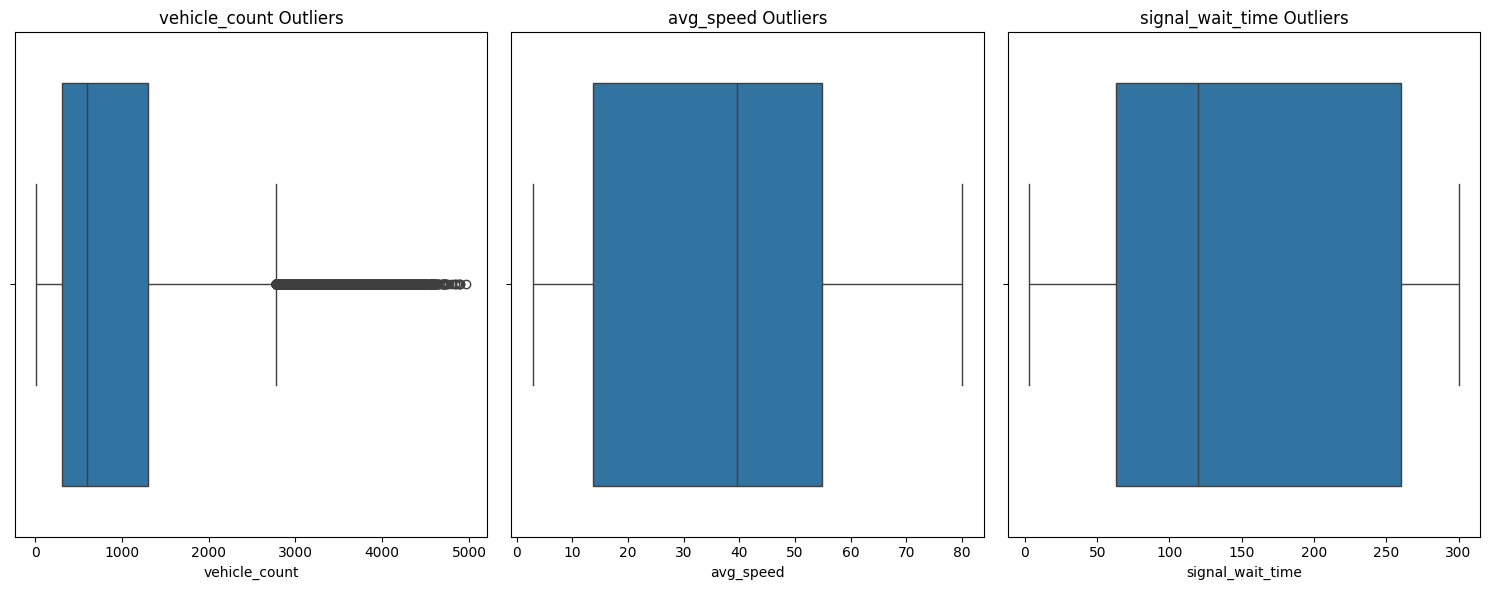

In [24]:
# Check for outliers using boxplot
features_t = ['vehicle_count', 'avg_speed', 'signal_wait_time']

# Convert only required columns from PySpark → Pandas
traffic_sample_pd = traffic.select(features_t).toPandas()
plt.figure(figsize=(15, 6))

for i, feat in enumerate(features_t, 1):   
    plt.subplot(1, 3, i)  
    sns.boxplot(x=traffic_sample_pd[feat])
    plt.title(f"{feat} Outliers")
    
plt.tight_layout()
plt.show()

In [25]:
# Count outliers using IQR
print("Outlier counts (before capping):")
outlier_counts(traffic, features_t)

Outlier counts (before capping):
vehicle_count outliers count: 19155


avg_speed outliers count: 0
signal_wait_time outliers count: 0


**Imputation**

In [26]:
num_col_t = [
    f.name for f in traffic.schema.fields
    if is_numeric(f) and f.name != "timestamp"
]

print("Numeric columns: ",num_col_t)

Numeric columns:  ['vehicle_count', 'avg_speed', 'signal_wait_time', 'is_weekend', 'is_it_hub', 'hour', 'day', 'dayofweek', 'month', 'year']


In [27]:
cat_col_t = [
    f.name for f in traffic.schema.fields
    if not is_numeric(f) and f.name != "timestamp"
]

print("Categorical columns: ", cat_col_t)

Categorical columns:  ['area', 'zone', 'congestion_level', 'road_type', 'weather', 'incident', 'severity', 'event', 'season']


In [28]:
traffic_clean = impute_numeric(traffic, num_col_t)

In [29]:
traffic_clean = impute_categorical(traffic_clean, cat_col_t)

In [30]:
# Check missing values after imputation
check_missing_values(traffic_clean, "(after imputation)")

Missing values (after imputation): 
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+-----+----------------+----------+---------+------+----+---+---------+-----+----+
|timestamp|area|zone|vehicle_count|avg_speed|congestion_level|road_type|weather|incident|severity|event|signal_wait_time|is_weekend|is_it_hub|season|hour|day|dayofweek|month|year|
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+-----+----------------+----------+---------+------+----+---+---------+-----+----+
|0        |0   |0   |0            |0        |0               |0        |0      |0       |0       |0    |0               |0         |0        |0     |0   |0  |0        |0    |0   |
+---------+----+----+-------------+---------+----------------+---------+-------+--------+--------+-----+----------------+----------+---------+------+----+---+---------+-----+----+



**Consistency Check**

In [31]:
print(
    "Invalid Vehicle Count (<0):",
    traffic_clean.filter(col('vehicle_count') < 0).count()
)

print(
    "Invalid Avg Speed (<0 or >120):",
    traffic_clean.filter(
        (col('avg_speed') < 0) |
        (col('avg_speed') > 120)
    ).count()
)

print(
    "Invalid Signal Wait Time (<0 or >300):",
    traffic_clean.filter(
        (col('signal_wait_time') < 0) |
        (col('signal_wait_time') > 300)
    ).count()
)

Invalid Vehicle Count (<0): 0
Invalid Avg Speed (<0 or >120): 0
Invalid Signal Wait Time (<0 or >300): 0


In [32]:
print(
    "Low congestion but high vehicles:",
    traffic_clean.filter(
        (col("congestion_level") == "Low") &
        (col("vehicle_count") > 800)
    ).count()
)

print(
    "High speed during heavy rain:",
    traffic_clean.filter(
        (col("weather") == "Heavy Rain") &
        (col("avg_speed") > 60)
    ).count()
)

print(
    "Low traffic + high wait:",
    traffic_clean.filter(
        (col("vehicle_count") < 100) &
        (col("signal_wait_time") > 200)
    ).count()
)

Low congestion but high vehicles: 0
High speed during heavy rain: 0
Low traffic + high wait: 0


**Outlier Handling**

In [33]:
for c in features_t:
    traffic_clean = cap_outliers(traffic_clean, c)

In [34]:
# Count outliers after capping
print("Outlier counts (after capping):")
outlier_counts(traffic_clean, features_t)

Outlier counts (after capping):
vehicle_count outliers count: 0
avg_speed outliers count: 0
signal_wait_time outliers count: 0


**Visualization**

In [35]:
# Convert to pandas for visualization
traffic_pd = traffic_clean.toPandas()

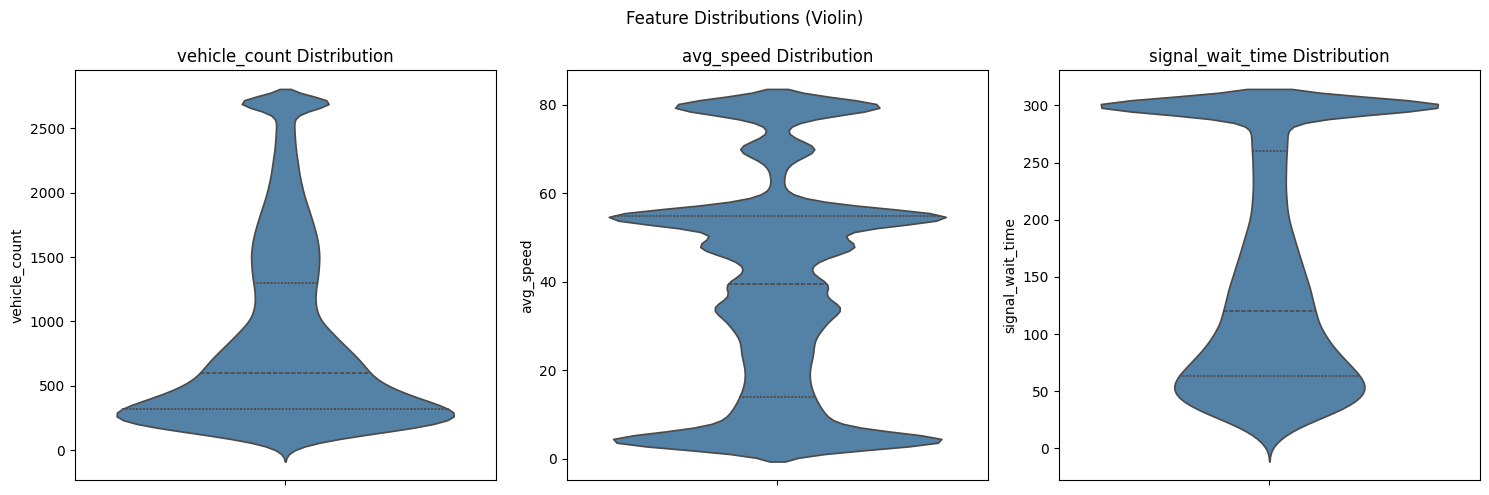

In [36]:
# DISTRIBUTION ANALYSIS

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat_col in zip(axes, ['vehicle_count', 'avg_speed', 'signal_wait_time']):
    sns.violinplot(y=traffic_pd[feat_col], ax=ax, inner='quartile', color='steelblue')
    ax.set_title(f"{feat_col} Distribution")
plt.suptitle("Feature Distributions (Violin)")
plt.tight_layout()
plt.show()

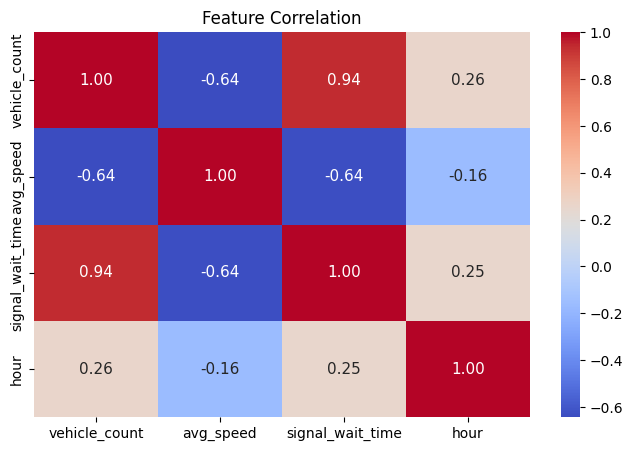

In [37]:
# CORRELATION ANALYSIS

plt.figure(figsize=(8,5))
corr_t = traffic_pd[['vehicle_count','avg_speed','signal_wait_time','hour']].corr()
sns.heatmap(corr_t, annot=True, fmt='.2f', annot_kws={"size": 11}, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

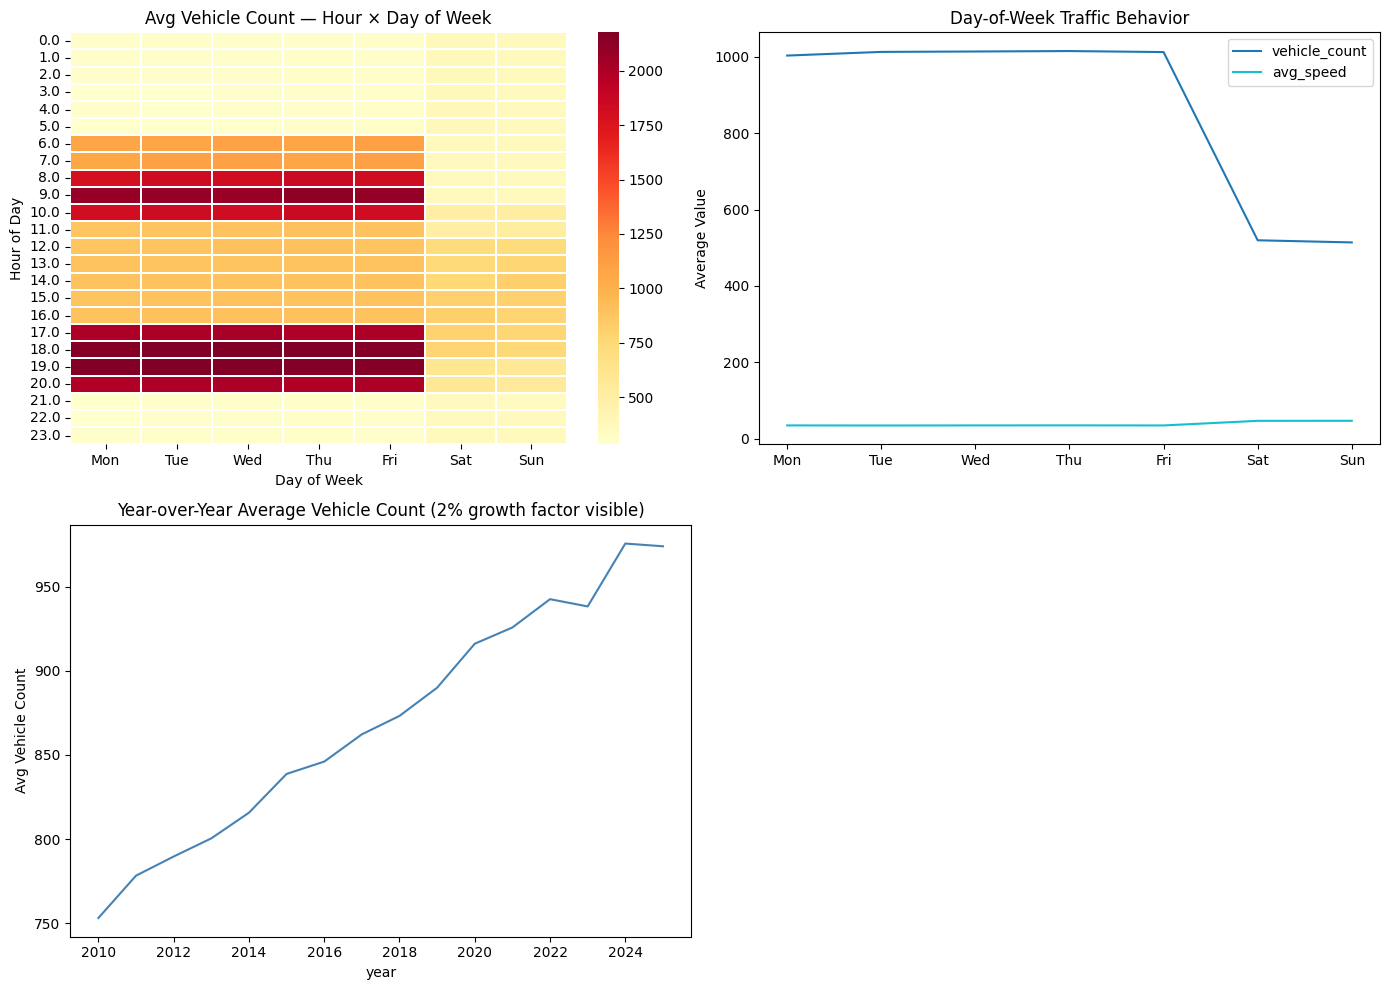

In [38]:
# TIME - BASED BEHAVIOUR

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pivot_hm = traffic_pd.pivot_table(
    values='vehicle_count', index='hour', columns='dayofweek', aggfunc='mean'
)
pivot_hm.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot_hm, cmap='YlOrRd', annot=False, fmt='.0f', linewidths=0.3, ax=axes[0,0])
axes[0,0].set_title("Avg Vehicle Count — Hour × Day of Week")
axes[0,0].set_xlabel("Day of Week")
axes[0,0].set_ylabel("Hour of Day")

daily_t = traffic_pd.groupby('dayofweek')[['vehicle_count','avg_speed']].mean()
daily_t.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_t.plot(ax=axes[0,1], colormap='tab10')
axes[0,1].set_title("Day-of-Week Traffic Behavior")
axes[0,1].set_ylabel("Average Value")
axes[0,1].tick_params(axis='x', rotation=0)

yoy_t = traffic_pd.groupby('year')['vehicle_count'].mean()
yoy_t.plot(ax=axes[1,0], color='steelblue')
axes[1,0].set_title("Year-over-Year Average Vehicle Count (2% growth factor visible)")
axes[1,0].set_ylabel("Avg Vehicle Count")
axes[1,0].tick_params(axis='x', rotation=0)

axes[1,1].axis('off')
plt.tight_layout()
plt.show()

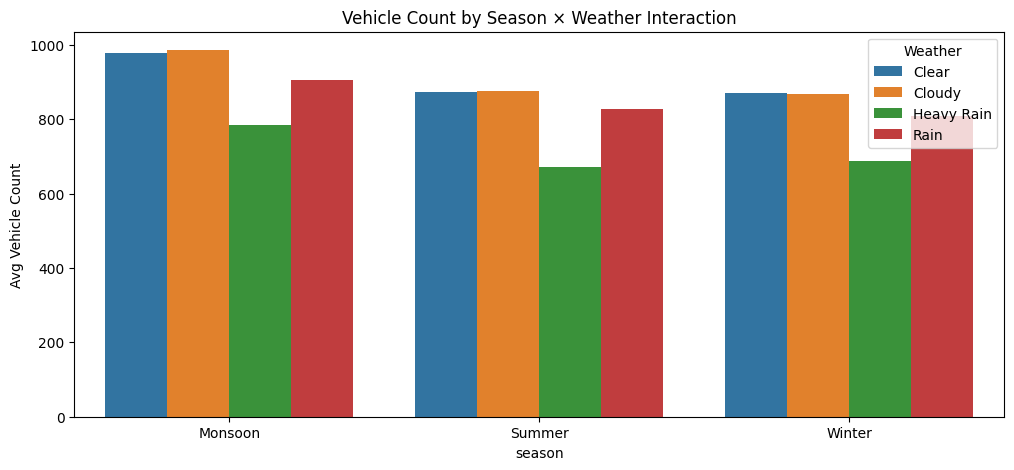

In [39]:
# WEATHER X SEASON IMPACT ANALYSIS

season_weather = traffic_pd.groupby(
    ['season', 'weather'])['vehicle_count'].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(x='season', y='vehicle_count', hue='weather', data=season_weather)
plt.title("Vehicle Count by Season × Weather Interaction")
plt.ylabel("Avg Vehicle Count")
plt.legend(title='Weather', loc='upper right')
plt.show()

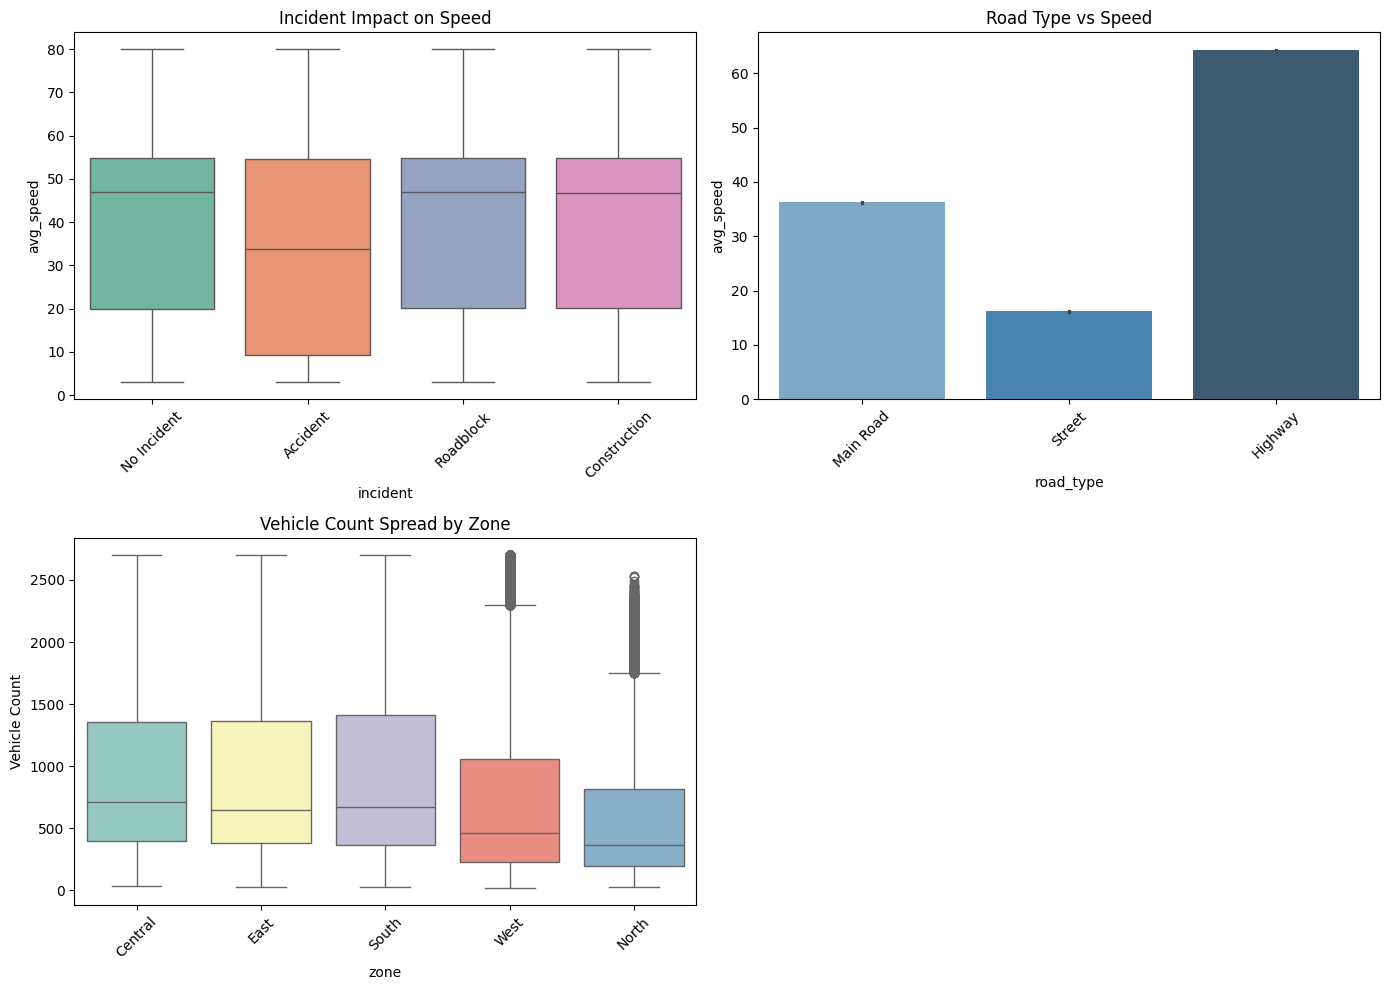

In [40]:
# INCIDENT, ROAD TYPE AND ZONE IMPACT ANALYSIS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='incident', y='avg_speed', data=traffic_pd, palette='Set2', ax=axes[0,0])
axes[0,0].set_title("Incident Impact on Speed")
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(x='road_type', y='avg_speed', data=traffic_pd, palette='Blues_d', ax=axes[0,1])
axes[0,1].set_title("Road Type vs Speed")
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(x='zone', y='vehicle_count', data=traffic_pd,
            palette='Set3', order=['Central','East','South','West','North'], ax=axes[1,0])
axes[1,0].set_title("Vehicle Count Spread by Zone")
axes[1,0].set_ylabel("Vehicle Count")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].axis('off')
plt.tight_layout()
plt.show()

In [41]:
# ── Save as PARQUET ─────────────────────────────
traffic_clean_parquet = "clean_data/traffic_clean.parquet"

traffic_clean.write \
    .mode("overwrite") \
    .parquet(traffic_clean_parquet)

# ── Save as CSV ─────────────────────────────────
traffic_clean_csv = "clean_data/traffic_clean_csv"

traffic_clean.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(traffic_clean_csv)

part_file = [f for f in os.listdir(traffic_clean_csv) if f.startswith("part-")][0]
shutil.move(
    os.path.join(traffic_clean_csv, part_file),
    "clean_data/traffic_clean.csv"
)

shutil.rmtree(traffic_clean_csv)

print(f"Traffic Parquet saved → {traffic_clean_parquet}")
print(f"Traffic CSV saved → clean_data/traffic_clean.csv")
print(f"Shape: ({traffic_clean.count()}, {len(traffic_clean.columns)})")

# Release cache after save
traffic.unpersist()

Traffic Parquet saved → clean_data/traffic_clean.parquet
Traffic CSV saved → clean_data/traffic_clean.csv
Shape: (499999, 20)


DataFrame[timestamp: timestamp, area: string, zone: string, vehicle_count: int, avg_speed: double, congestion_level: string, road_type: string, weather: string, incident: string, severity: string, event: string, signal_wait_time: int, is_weekend: int, is_it_hub: int, season: string, hour: int, day: int, dayofweek: int, month: int, year: int]

# ============================================ 
# ⚡ ENERGY DATASET
# ============================================

**Load Dataset**

In [42]:
energy = spark.read.csv(
    "energy.csv",
    header=True,
    inferSchema=True,
    nullValue=""
)

energy.cache()

DataFrame[timestamp: timestamp, area: string, zone: string, weather: string, energy_consumption: double, temperature: double, humidity: double, demand_level: string, renewable_usage: double, load_type: string, is_weekend: int, power_outage: int, is_it_hub: int, season: string, generator_version: string]

**Data Inspection**

In [43]:
print("Shape:", (energy.count(), len(energy.columns)))

Shape: (500000, 15)


In [44]:
energy.show()

+-------------------+-----------+-------+-------+------------------+-----------+--------+------------+---------------+-----------+----------+------------+---------+------+-----------------+
|          timestamp|       area|   zone|weather|energy_consumption|temperature|humidity|demand_level|renewable_usage|  load_type|is_weekend|power_outage|is_it_hub|season|generator_version|
+-------------------+-----------+-------+-------+------------------+-----------+--------+------------+---------------+-----------+----------+------------+---------+------+-----------------+
|2010-01-01 00:57:16|Thanisandra|  North|  Clear|            3603.2|       21.1|    53.3|      Medium|            1.8|Residential|         0|           0|        0|Winter|   smartcity_v5.0|
|2010-01-01 00:59:19|   JP Nagar|  South|  Clear|            3545.1|       19.2|    49.4|      Medium|            0.0| Commercial|         0|           0|        1|Winter|   smartcity_v5.0|
|2010-01-01 01:24:51|   JP Nagar|  South|  Clear| 

In [45]:
energy.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- weather: string (nullable = true)
 |-- energy_consumption: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- demand_level: string (nullable = true)
 |-- renewable_usage: double (nullable = true)
 |-- load_type: string (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- power_outage: integer (nullable = true)
 |-- is_it_hub: integer (nullable = true)
 |-- season: string (nullable = true)
 |-- generator_version: string (nullable = true)



**Preprocessing**

In [46]:
# Check missing values
check_missing_values(energy, "(before imputation)")

Missing values (before imputation): 
+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+-----------------+
|timestamp|area|zone|weather|energy_consumption|temperature|humidity|demand_level|renewable_usage|load_type|is_weekend|power_outage|is_it_hub|season|generator_version|
+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+-----------------+
|0        |0   |0   |0      |8737              |0          |0       |0           |0              |0        |0         |0           |0        |0     |0                |
+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+-----------------+



In [47]:
# Check duplicates
duplicate_count = energy.count() - energy.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [48]:
# Remove duplicates
energy = energy.dropDuplicates()

In [49]:
# Drop generator metadata column
energy = energy.drop('generator_version')

In [50]:
# Basic Feature Engineering - Timestamp parsing
energy = energy.withColumn(
    "timestamp",
    to_timestamp(col("timestamp"))
).filter(col("timestamp").isNotNull())

energy = energy.withColumn("hour", hour(col("timestamp"))) \
                 .withColumn("day", dayofmonth(col("timestamp"))) \
                 .withColumn("dayofweek", ((dayofweek(col("timestamp")) + 5)%7)) \
                 .withColumn("month", month(col("timestamp"))) \
                 .withColumn("year", year(col("timestamp")))

energy.show()

+-------------------+------------+-------+----------+------------------+-----------+--------+------------+---------------+-----------+----------+------------+---------+------+----+---+---------+-----+----+
|          timestamp|        area|   zone|   weather|energy_consumption|temperature|humidity|demand_level|renewable_usage|  load_type|is_weekend|power_outage|is_it_hub|season|hour|day|dayofweek|month|year|
+-------------------+------------+-------+----------+------------------+-----------+--------+------------+---------------+-----------+----------+------------+---------+------+----+---+---------+-----+----+
|2010-01-01 00:59:19|    JP Nagar|  South|     Clear|            3545.1|       19.2|    49.4|      Medium|            0.0| Commercial|         0|           0|        1|Winter|   0|  1|        4|    1|2010|
|2010-01-01 06:32:51| Cubbon Park|Central|     Clear|            3200.5|       23.2|    48.8|      Medium|            1.9| Commercial|         0|           0|        0|Winter| 

In [51]:
print("Shape:", (energy.count(), len(energy.columns)))

Shape: (500000, 19)


**Outlier Detection**

In [52]:
energy.select(
    'energy_consumption',
    'temperature',
    'humidity',
    'renewable_usage'
).describe().show()

+-------+------------------+------------------+------------------+------------------+
|summary|energy_consumption|       temperature|          humidity|   renewable_usage|
+-------+------------------+------------------+------------------+------------------+
|  count|            491263|            500000|            500000|            500000|
|   mean|   5645.9721163613| 25.93663519999988| 60.16764900000009|15.244983399999935|
| stddev| 2557.020679582466|5.0392876332831635|13.498746447915437|16.563543163696817|
|    min|            1539.9|              14.0|              35.0|               0.0|
|    max|          113261.0|              41.0|              95.0|              45.0|
+-------+------------------+------------------+------------------+------------------+



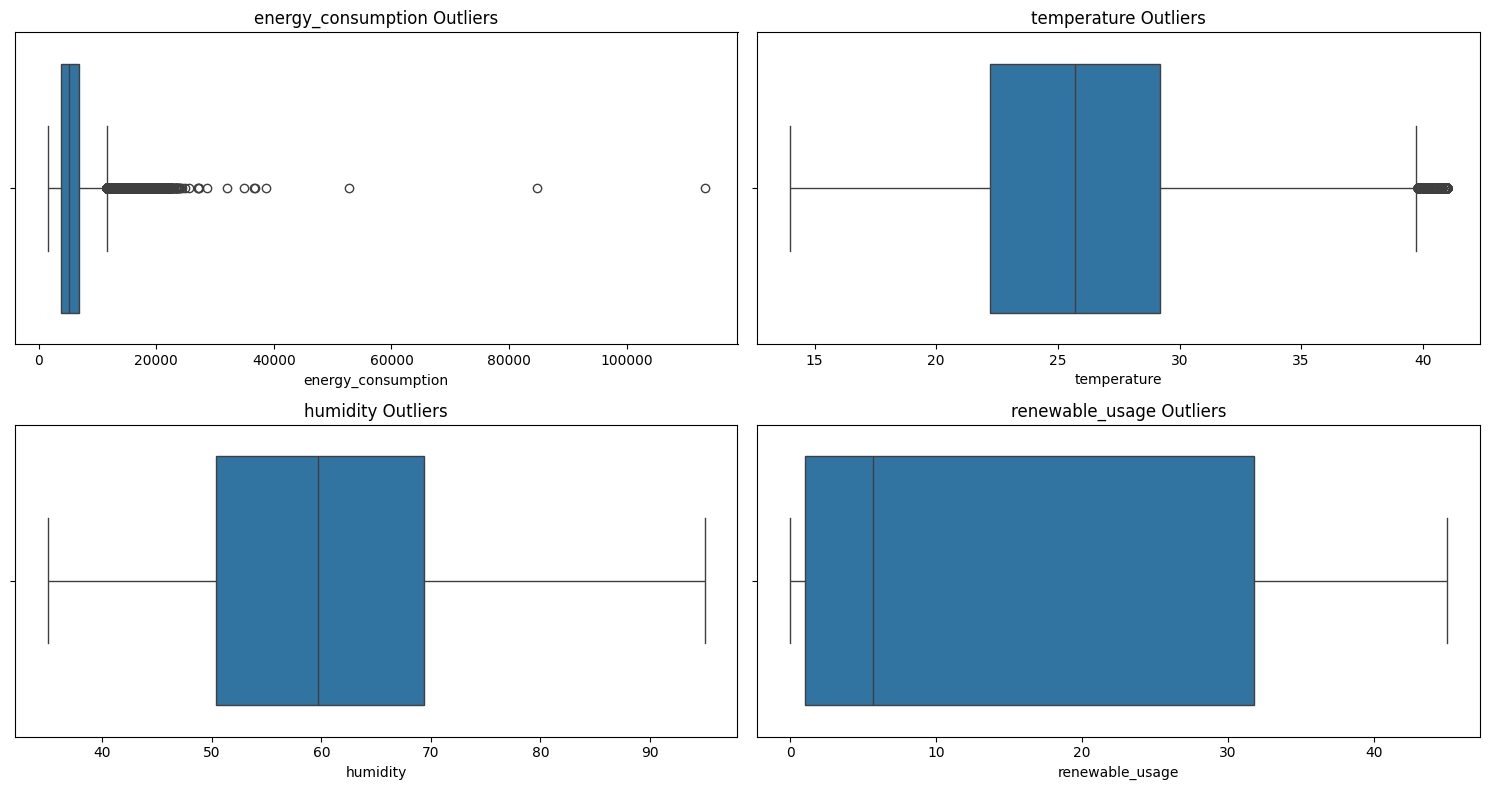

In [53]:
# Check for outliers using boxplot
features_e = ['energy_consumption', 'temperature', 'humidity', 'renewable_usage']

# Convert only required columns from PySpark → Pandas
energy_sample_pd = energy.select(features_e).toPandas()
plt.figure(figsize=(15, 8))

for i, feat in enumerate(features_e, 1):   
    plt.subplot(2, 2, i)  
    sns.boxplot(x=energy_sample_pd[feat])
    plt.title(f"{feat} Outliers")
    
plt.tight_layout()
plt.show()

In [54]:
# Count outliers using IQR
print("Outlier counts (before capping):")
outlier_counts(energy, features_e)

Outlier counts (before capping):
energy_consumption outliers count: 15740
temperature outliers count: 709
humidity outliers count: 0
renewable_usage outliers count: 0


**Imputation**

In [55]:
num_col_e = [
    f.name for f in energy.schema.fields
    if is_numeric(f) and f.name != "timestamp"
]

print("Numeric columns: ", num_col_e)

Numeric columns:  ['energy_consumption', 'temperature', 'humidity', 'renewable_usage', 'is_weekend', 'power_outage', 'is_it_hub', 'hour', 'day', 'dayofweek', 'month', 'year']


In [56]:
cat_col_e = [
    f.name for f in energy.schema.fields
    if not is_numeric(f) and f.name != "timestamp"
]

print("Categorical columns: ", cat_col_e)

Categorical columns:  ['area', 'zone', 'weather', 'demand_level', 'load_type', 'season']


In [57]:
energy_clean = impute_numeric(energy, num_col_e)

In [58]:
energy_clean = impute_categorical(energy_clean, cat_col_e)

In [59]:
# Check missing values after imputation
check_missing_values(energy_clean, "(after imputation)")

Missing values (after imputation): 


+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+----+---+---------+-----+----+
|timestamp|area|zone|weather|energy_consumption|temperature|humidity|demand_level|renewable_usage|load_type|is_weekend|power_outage|is_it_hub|season|hour|day|dayofweek|month|year|
+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+----+---+---------+-----+----+
|0        |0   |0   |0      |0                 |0          |0       |0           |0              |0        |0         |0           |0        |0     |0   |0  |0        |0    |0   |
+---------+----+----+-------+------------------+-----------+--------+------------+---------------+---------+----------+------------+---------+------+----+---+---------+-----+----+



**Consistency Check**

In [60]:
print(
    "Invalid Energy (<0):",
    energy_clean.filter(col("energy_consumption") < 0).count()
)

print(
    "Invalid Temperature (< -50 or > 60):",
    energy_clean.filter(
        (col("temperature") < -50) |
        (col("temperature") > 60)
    ).count()
)

print(
    "Invalid Humidity (<0 or >100):",
    energy_clean.filter(
        (col("humidity") < 0) |
        (col("humidity") > 100)
    ).count()
)

print(
    "Invalid Renewable Usage (<0 or >100):",
    energy_clean.filter(
        (col("renewable_usage") < 0) |
        (col("renewable_usage") > 100)
    ).count()
)

Invalid Energy (<0): 0
Invalid Temperature (< -50 or > 60): 0
Invalid Humidity (<0 or >100): 0
Invalid Renewable Usage (<0 or >100): 0


In [61]:
print(
    "High Demand but Energy < 3000:",
    energy_clean.filter(
        (col("demand_level") == "High") &
        (col("energy_consumption") < 3000)
    ).count()
)

print(
    "Low Demand but Energy > 6500:",
    energy_clean.filter(
        (col("demand_level") == "Low") &
        (col("energy_consumption") > 6500)
    ).count()
)

print(
    "Night Time (0-5 hrs) but Renewable > 20:",
    energy_clean.filter(
        (col("hour").isin([0,1,2,3,4,5])) &
        (col("renewable_usage") > 20)
    ).count()
)

print(
    "Day Time (10-16 hrs) but Renewable < 1:",
    energy_clean.filter(
        (col("hour").between(10,16)) &
        (col("renewable_usage") < 1)
    ).count()
)

High Demand but Energy < 3000: 0
Low Demand but Energy > 6500: 3
Night Time (0-5 hrs) but Renewable > 20: 0
Day Time (10-16 hrs) but Renewable < 1: 0


**Outliers Handling**

In [62]:
for c in features_e:
    energy_clean = cap_outliers(energy_clean, c)

In [63]:
# Count outliers after capping
print("Outlier counts (after capping):")
outlier_counts(energy_clean, features_e)

Outlier counts (after capping):
energy_consumption outliers count: 0
temperature outliers count: 0
humidity outliers count: 0
renewable_usage outliers count: 0


**Visualization**

In [64]:
energy_pd = energy_clean.toPandas()

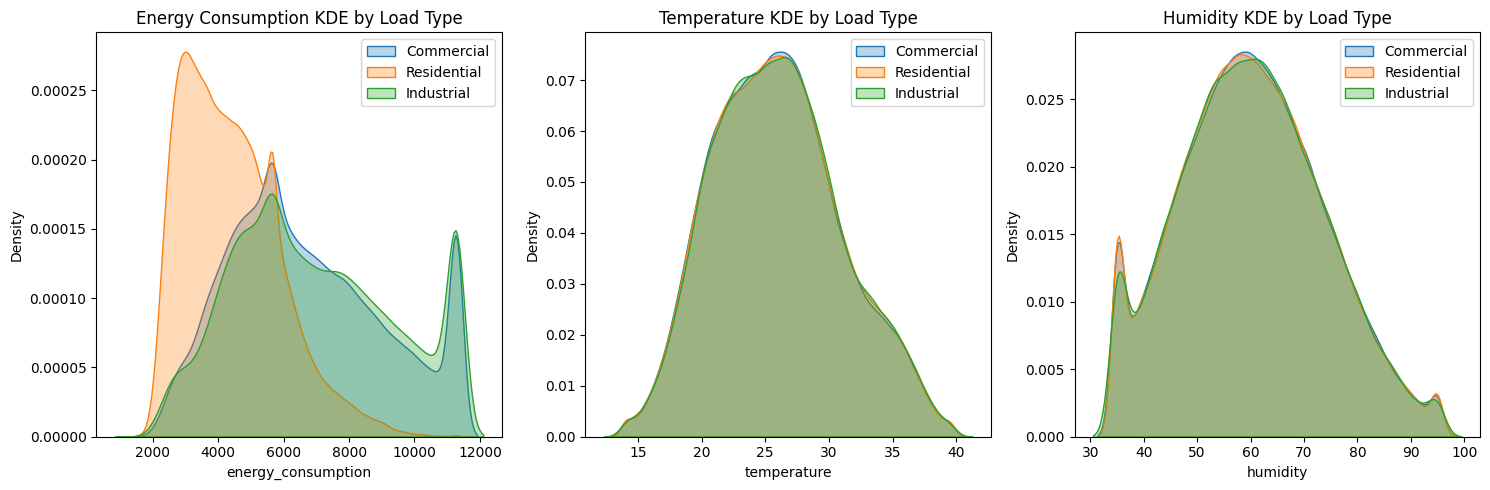

In [65]:
# DISTRIBUTION BY LOAD_TYPE (KDE)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
for lt in energy_pd['load_type'].unique():
    sns.kdeplot(energy_pd[energy_pd['load_type']==lt]['energy_consumption'],
                label=lt, fill=True, alpha=0.3)
plt.title("Energy Consumption KDE by Load Type")
plt.legend()
plt.subplot(1, 3, 2)
for lt in energy_pd['load_type'].unique():
    sns.kdeplot(energy_pd[energy_pd['load_type']==lt]['temperature'],
                label=lt, fill=True, alpha=0.3)
plt.title("Temperature KDE by Load Type")
plt.legend()
plt.subplot(1, 3, 3)
for lt in energy_pd['load_type'].unique():
    sns.kdeplot(energy_pd[energy_pd['load_type']==lt]['humidity'],
                label=lt, fill=True, alpha=0.3)
plt.title("Humidity KDE by Load Type")
plt.legend()
plt.tight_layout()
plt.show()

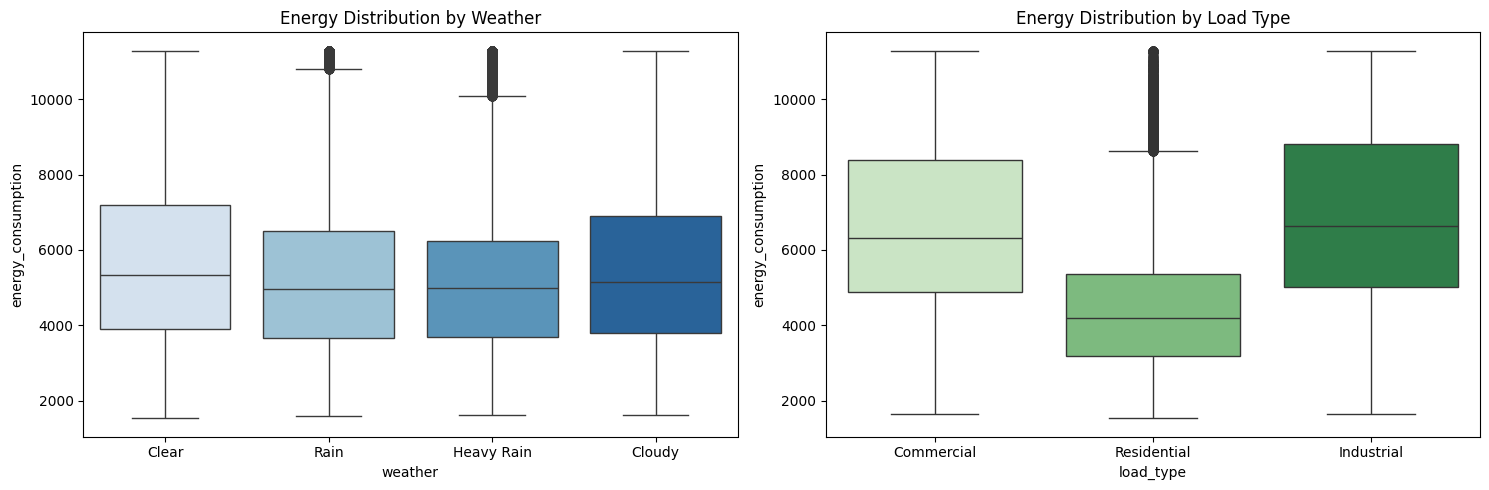

In [66]:
# WEATHER AND LOAD_TYPE 

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='weather', y='energy_consumption',
            data=energy_pd, ax=axes[0], palette='Blues')
axes[0].set_title("Energy Distribution by Weather")
sns.boxplot(x='load_type', y='energy_consumption',
            data=energy_pd, ax=axes[1], palette='Greens')
axes[1].set_title("Energy Distribution by Load Type")
plt.tight_layout()
plt.show()

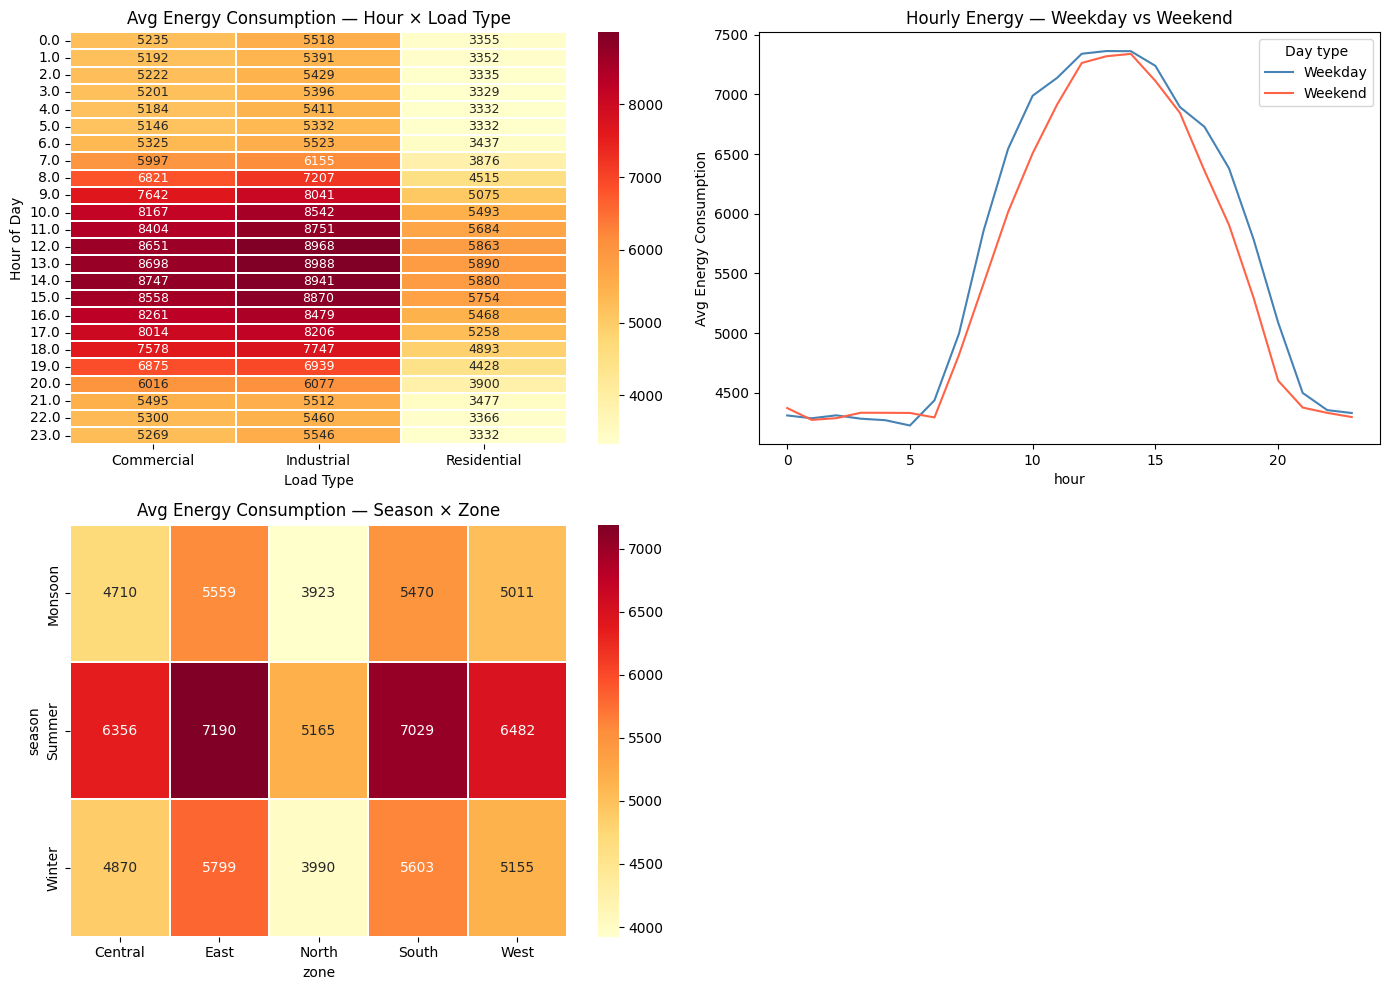

In [67]:
# TIME - BASED BEHAVIOR

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pivot_e = energy_pd.pivot_table(
    values='energy_consumption', index='hour',
    columns='load_type', aggfunc='mean'
)
sns.heatmap(pivot_e, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, annot_kws={'size': 9}, ax=axes[0,0])
axes[0,0].set_title("Avg Energy Consumption — Hour × Load Type")
axes[0,0].set_xlabel("Load Type")
axes[0,0].set_ylabel("Hour of Day")

hourly_e_wk = energy_pd.groupby(
    ['hour','is_weekend'])['energy_consumption'].mean().reset_index()
hourly_e_wk['Day type'] = hourly_e_wk['is_weekend'].map({0:'Weekday', 1:'Weekend'})
sns.lineplot(x='hour', y='energy_consumption', hue='Day type',
             data=hourly_e_wk, palette=['steelblue','tomato'], ax=axes[0,1])
axes[0,1].set_title("Hourly Energy — Weekday vs Weekend")
axes[0,1].set_ylabel("Avg Energy Consumption")

pivot_sz = energy_pd.pivot_table(
    values='energy_consumption', index='season',
    columns='zone', aggfunc='mean'
)
sns.heatmap(pivot_sz, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, annot_kws={'size': 10}, ax=axes[1,0])
axes[1,0].set_title("Avg Energy Consumption — Season × Zone")
axes[1,1].axis('off')
plt.tight_layout()
plt.show()

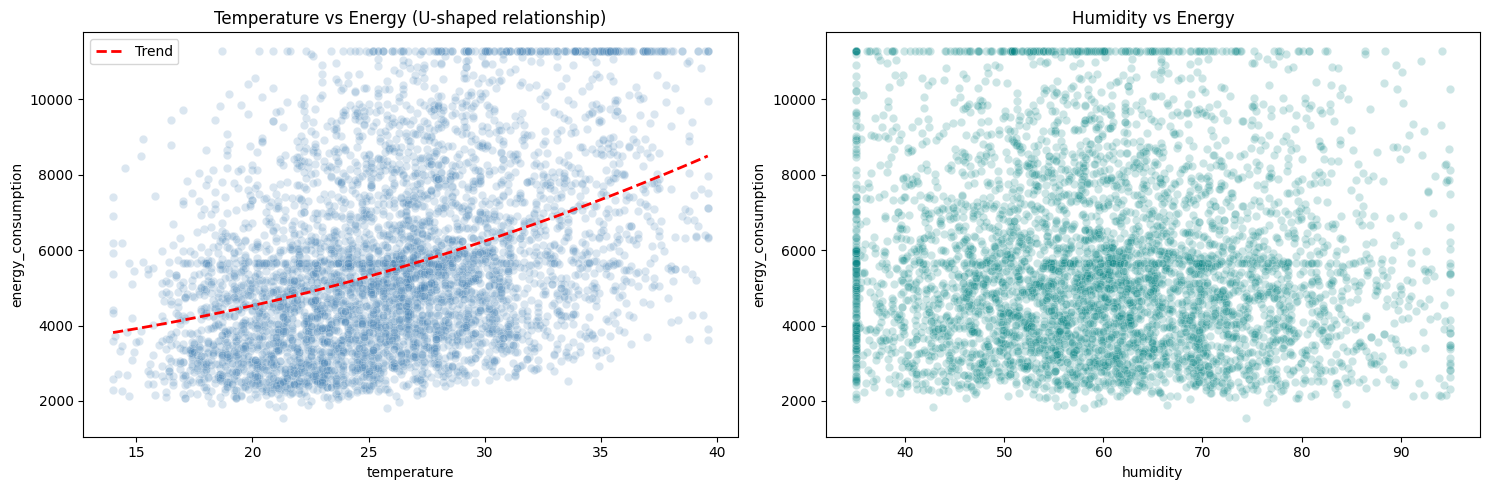

In [68]:
# ENVIRONMENT IMPACT

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sample_e = energy_pd.sample(min(5000, len(energy_pd)), random_state=42)
sns.scatterplot(x='temperature', y='energy_consumption',
                data=sample_e, alpha=0.2, color='steelblue')
# regression line
z = np.polyfit(sample_e['temperature'], sample_e['energy_consumption'], 2)
p = np.poly1d(z)
x_line = np.linspace(sample_e['temperature'].min(), sample_e['temperature'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', lw=2, label='Trend')
plt.title("Temperature vs Energy (U-shaped relationship)")
plt.legend()

plt.subplot(1,2,2)
sns.scatterplot(x='humidity', y='energy_consumption', data=sample_e, alpha=0.2, color='teal')
plt.title("Humidity vs Energy")

plt.tight_layout()
plt.show()


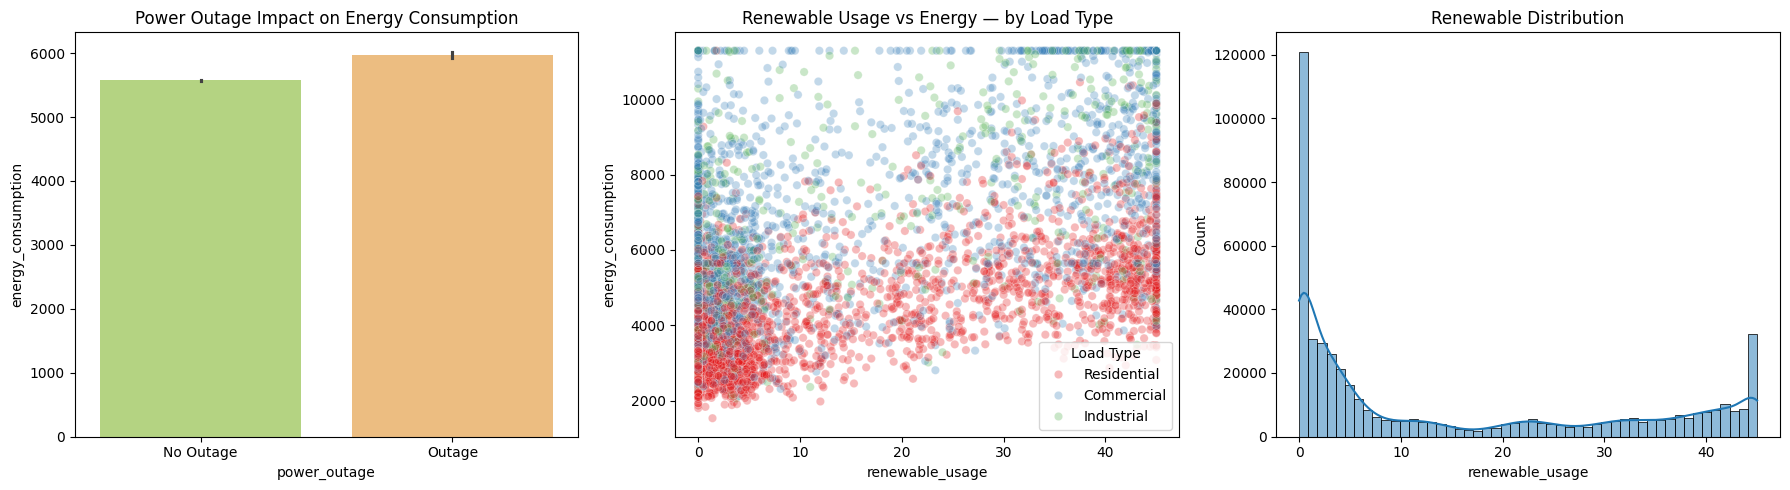

In [69]:
# SYSTEM BEHAVIOR

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='power_outage', y='energy_consumption',
            data=energy_pd, palette='RdYlGn_r', ax=axes[0])
axes[0].set_title("Power Outage Impact on Energy Consumption")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Outage', 'Outage'])

sns.scatterplot(x='renewable_usage', y='energy_consumption',
                hue='load_type', data=sample_e, alpha=0.3, palette='Set1', ax=axes[1])
axes[1].set_title("Renewable Usage vs Energy — by Load Type")
axes[1].legend(title='Load Type')

sns.histplot(energy_pd['renewable_usage'], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Renewable Distribution")
plt.tight_layout()
plt.show()

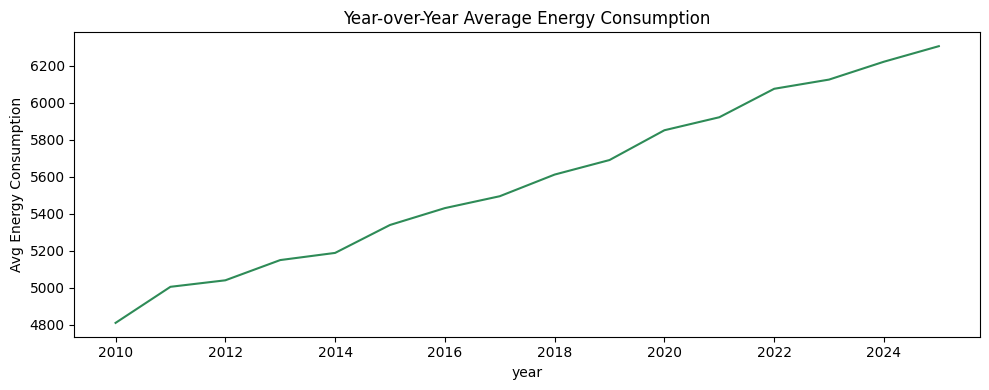

In [70]:
# YEAR OVER YEAR ENERGY GROWTH

yoy_e = energy_pd.groupby('year')['energy_consumption'].mean()
yoy_e.plot(figsize=(10, 4), color='seagreen')
plt.title("Year-over-Year Average Energy Consumption")
plt.ylabel("Avg Energy Consumption")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

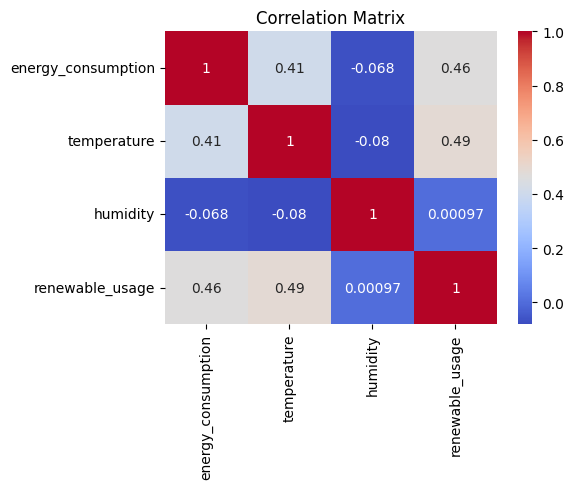

In [71]:
# CORRELATION ANALYSIS

plt.figure(figsize=(6,5))

corr_cols_e = ['energy_consumption', 'temperature', 'humidity', 'renewable_usage']

sns.heatmap(energy_pd[corr_cols_e].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [75]:
# ── Save as PARQUET ─────────────────────────────
energy_clean_parquet = "clean_data/energy_clean.parquet"

energy_clean.write \
    .mode("overwrite") \
    .parquet(energy_clean_parquet)

# ── Save as CSV ─────────────────────────────────
energy_clean_csv = "clean_data/energy_clean_csv"

energy_clean.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(energy_clean_csv)

part_file = [f for f in os.listdir(energy_clean_csv) if f.startswith("part-")][0]
shutil.move(
    os.path.join(energy_clean_csv, part_file),
    "clean_data/energy_clean.csv"
)

shutil.rmtree(energy_clean_csv)

print(f"Energy Parquet saved → {energy_clean_parquet}")
print(f"Energy CSV saved → clean_data/energy_clean.csv")
print(f"Shape: ({energy_clean.count()}, {len(energy_clean.columns)})")

# Release cache after save
energy.unpersist()

Energy Parquet saved → clean_data/energy_clean.parquet
Energy CSV saved → clean_data/energy_clean.csv
Shape: (500000, 19)


DataFrame[timestamp: timestamp, area: string, zone: string, weather: string, energy_consumption: double, temperature: double, humidity: double, demand_level: string, renewable_usage: double, load_type: string, is_weekend: int, power_outage: int, is_it_hub: int, season: string, hour: int, day: int, dayofweek: int, month: int, year: int]

# ============================================
# 🌫️ POLLUTION DATASET
# ============================================

**Load Dataset**

In [76]:
pollution = spark.read.csv(
    "pollution.csv",
    header=True,
    inferSchema=True,
    nullValue=""
)

pollution.cache()

DataFrame[timestamp: timestamp, area: string, zone: string, AQI: int, PM2.5: double, PM10: double, NO2: double, CO: double, weather: string, temperature: double, humidity: double, is_weekend: int, is_it_hub: int, season: string, generator_version: string]

**Data Inspection**

In [77]:
print("Shape:", (pollution.count(), len(pollution.columns)))

Shape: (500000, 15)


In [78]:
pollution.show()

+-------------------+-----------+-------+---+-----+-----+----+----+-------+-----------+--------+----------+---------+------+-----------------+
|          timestamp|       area|   zone|AQI|PM2.5| PM10| NO2|  CO|weather|temperature|humidity|is_weekend|is_it_hub|season|generator_version|
+-------------------+-----------+-------+---+-----+-----+----+----+-------+-----------+--------+----------+---------+------+-----------------+
|2010-01-01 00:57:16|Thanisandra|  North|120| 82.2|107.6|31.3|2.38|  Clear|       21.1|    53.3|         0|        0|Winter|   smartcity_v5.0|
|2010-01-01 00:59:19|   JP Nagar|  South|128| 66.1|108.7|31.3|1.74|  Clear|       19.2|    49.4|         0|        1|Winter|   smartcity_v5.0|
|2010-01-01 01:24:51|   JP Nagar|  South|149| 77.2|126.7|38.7|2.57|  Clear|       23.5|    52.3|         0|        1|Winter|   smartcity_v5.0|
|2010-01-01 01:27:49|   JP Nagar|  South|158| 93.3|106.0|37.6|2.92|  Clear|       19.3|    77.2|         0|        1|Winter|   smartcity_v5.0|

In [79]:
pollution.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- area: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- AQI: integer (nullable = true)
 |-- PM2.5: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- weather: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_it_hub: integer (nullable = true)
 |-- season: string (nullable = true)
 |-- generator_version: string (nullable = true)



In [80]:
pollution = pollution.withColumnRenamed("PM2.5", "PM2_5")

**Preprocessing**

In [81]:
# Check missing values
check_missing_values(pollution, "(before imputation)")

Missing values (before imputation): 
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+-----------------+
|timestamp|area|zone|AQI|PM2_5|PM10|NO2|CO |weather|temperature|humidity|is_weekend|is_it_hub|season|generator_version|
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+-----------------+
|0        |0   |0   |0  |0    |0   |0  |0  |0      |0          |0       |0         |0        |0     |0                |
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+-----------------+



In [82]:
# Check duplicates
duplicate_count = pollution.count() - pollution.dropDuplicates().count()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [83]:
# Remove duplicates
pollution = pollution.dropDuplicates()

In [84]:
# Drop generator metadata column
pollution = pollution.drop('generator_version')

In [85]:
# Basic Feature Engineering - Timestamp parsing
pollution = pollution.withColumn(
    "timestamp",
    to_timestamp(col("timestamp"))
).filter(col("timestamp").isNotNull())

pollution = pollution.withColumn("hour", hour(col("timestamp"))) \
                     .withColumn("day", dayofmonth(col("timestamp"))) \
                     .withColumn("dayofweek", ((dayofweek(col("timestamp")) + 5)%7)) \
                     .withColumn("month", month(col("timestamp"))) \
                     .withColumn("year", year(col("timestamp")))

pollution.show()

+-------------------+-----------------+-------+---+-----+-----+-----+----+----------+-----------+--------+----------+---------+------+----+---+---------+-----+----+
|          timestamp|             area|   zone|AQI|PM2_5| PM10|  NO2|  CO|   weather|temperature|humidity|is_weekend|is_it_hub|season|hour|day|dayofweek|month|year|
+-------------------+-----------------+-------+---+-----+-----+-----+----+----------+-----------+--------+----------+---------+------+----+---+---------+-----+----+
|2010-01-01 00:59:19|         JP Nagar|  South|128| 66.1|108.7| 31.3|1.74|     Clear|       19.2|    49.4|         0|        1|Winter|   0|  1|        4|    1|2010|
|2010-01-01 01:24:51|         JP Nagar|  South|149| 77.2|126.7| 38.7|2.57|     Clear|       23.5|    52.3|         0|        1|Winter|   1|  1|        4|    1|2010|
|2010-01-01 03:17:38|         JP Nagar|  South|181|105.7|144.8| 51.1|2.46|    Cloudy|       22.7|    73.5|         0|        1|Winter|   3|  1|        4|    1|2010|
|2010-01-0

In [86]:
print("Shape:", (pollution.count(), len(pollution.columns)))

Shape: (500000, 19)


**Outlier Detection**

In [87]:
pollution.select(
    'AQI',
    'PM2_5',
    'PM10',
    'NO2',
    'CO',
    'temperature',
    'humidity',
).describe().show()

+-------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|              AQI|             PM2_5|              PM10|              NO2|                CO|       temperature|          humidity|
+-------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|           500000|            500000|            500000|           500000|            500000|            500000|            500000|
|   mean|       257.675464|149.46969639999992|211.28252820000012|72.14914919999984| 4.637282819999997|25.936635199999905| 60.16764900000011|
| stddev|78.79784074823455| 46.39127956538229| 65.70399822253566|22.62633652225543|1.4730297373665158|5.0392876332831635|13.498746447915478|
|    min|               20|               5.0|              15.0|              3.0|               0.3|              14.0|              35.0|
|    max|    

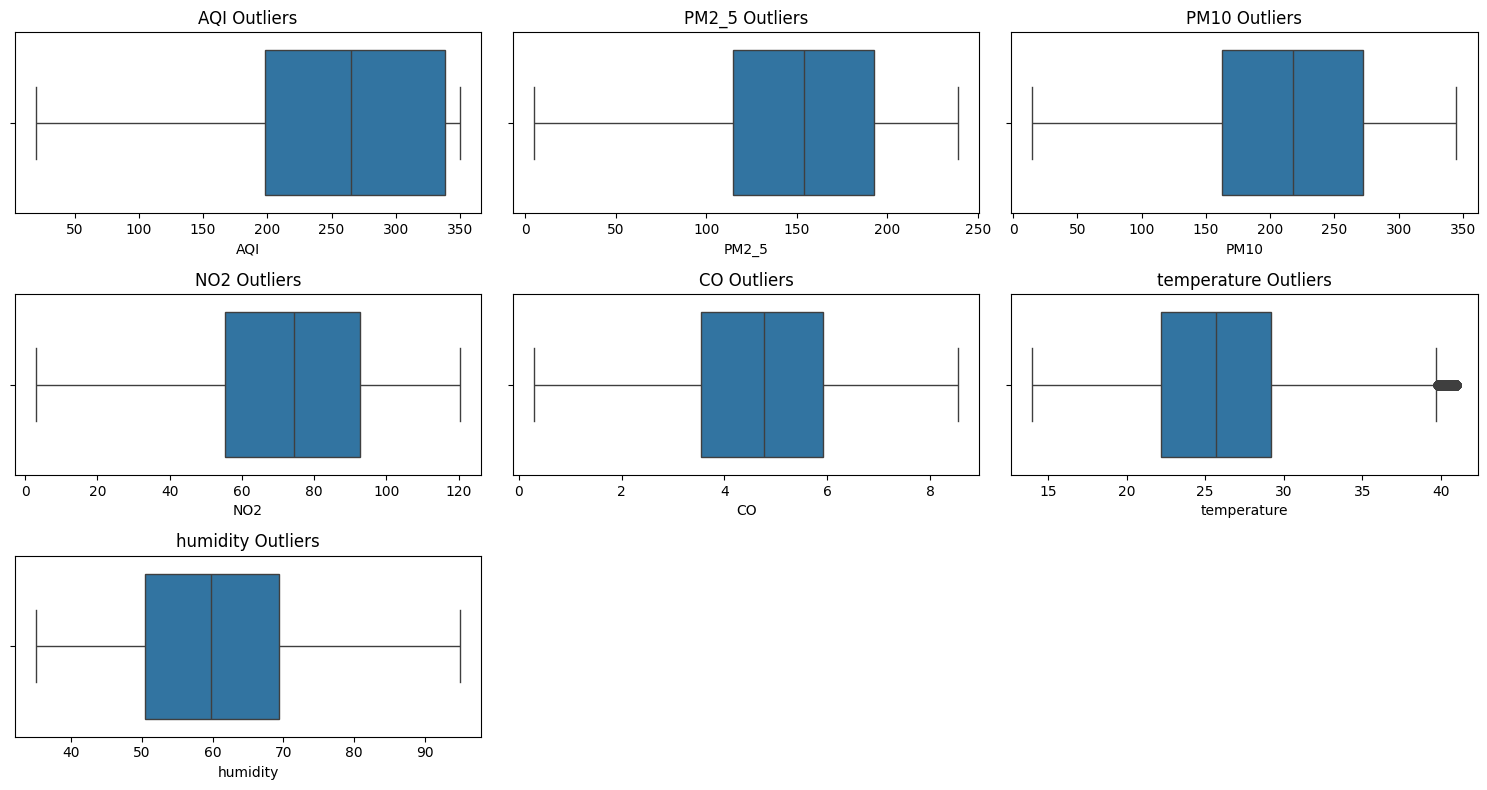

In [88]:
# Check for outliers using boxplot
features_p = ['AQI', 'PM2_5', 'PM10', 'NO2', 'CO', 'temperature', 'humidity']

# Convert only required columns from PySpark → Pandas
pollution_sample_pd = pollution.select(features_p).toPandas()
plt.figure(figsize=(15, 8))

for i, feat in enumerate(features_p, 1):   
    plt.subplot(3, 3, i)  
    sns.boxplot(x=pollution_sample_pd[feat])
    plt.title(f"{feat} Outliers")
for j in range(len(features_p)+1, 10):
    plt.subplot(3, 3, j)
    plt.axis('off')   
plt.tight_layout()
plt.show()

In [89]:
# Count outliers using IQR
print("Outlier counts (before capping):")
outlier_counts(pollution, features_p)

Outlier counts (before capping):
AQI outliers count: 0
PM2_5 outliers count: 0
PM10 outliers count: 0
NO2 outliers count: 0
CO outliers count: 0
temperature outliers count: 709
humidity outliers count: 0


**Imputation**

In [90]:
num_col_p = [
    f.name for f in pollution.schema.fields
    if is_numeric(f) and f.name != "timestamp"
]

print("Numeric columns: ", num_col_p)

Numeric columns:  ['AQI', 'PM2_5', 'PM10', 'NO2', 'CO', 'temperature', 'humidity', 'is_weekend', 'is_it_hub', 'hour', 'day', 'dayofweek', 'month', 'year']


In [91]:
cat_col_p = [
    f.name for f in pollution.schema.fields
    if not is_numeric(f) and f.name != "timestamp"
]

print("Categorical columns: ", cat_col_p)

Categorical columns:  ['area', 'zone', 'weather', 'season']


In [92]:
pollution_clean = impute_numeric(pollution, num_col_p)

In [93]:
pollution_clean = impute_categorical(pollution_clean, cat_col_p)

In [94]:
# Check missing values after imputation
check_missing_values(pollution_clean, "(after imputation)")

Missing values (after imputation): 
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+----+---+---------+-----+----+
|timestamp|area|zone|AQI|PM2_5|PM10|NO2|CO |weather|temperature|humidity|is_weekend|is_it_hub|season|hour|day|dayofweek|month|year|
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+----+---+---------+-----+----+
|0        |0   |0   |0  |0    |0   |0  |0  |0      |0          |0       |0         |0        |0     |0   |0  |0        |0    |0   |
+---------+----+----+---+-----+----+---+---+-------+-----------+--------+----------+---------+------+----+---+---------+-----+----+



**Consistency Check**

In [95]:
print(
    "\nInvalid AQI:",
    pollution_clean.filter(col("AQI") < 0).count()
)

print(
    "Invalid PM2_5:",
    pollution_clean.filter(col("PM2_5") < 0).count()
)

print(
    "Invalid PM10:",
    pollution_clean.filter(col("PM10") < 0).count()
)

print(
    "Invalid NO2:",
    pollution_clean.filter(col("NO2") < 0).count()
)

print(
    "Invalid CO:",
    pollution_clean.filter(col("CO") < 0).count()
)

print(
    "Invalid Temperature:",
    pollution_clean.filter(col("temperature") < -50).count()
)

print(
    "Invalid Humidity:",
    pollution_clean.filter(col("humidity") < 0).count()
)


Invalid AQI: 0
Invalid PM2_5: 0
Invalid PM10: 0
Invalid NO2: 0
Invalid CO: 0
Invalid Temperature: 0
Invalid Humidity: 0


**Outliers Handling**

In [96]:
for c in features_p:
    pollution_clean = cap_outliers(pollution_clean, c)

In [97]:
# Count outliers after capping
print("Outlier counts (after capping):")
outlier_counts(pollution_clean, features_p)

Outlier counts (after capping):


AQI outliers count: 0
PM2_5 outliers count: 0
PM10 outliers count: 0
NO2 outliers count: 0
CO outliers count: 0
temperature outliers count: 0
humidity outliers count: 0


**Visualization**

In [98]:
pollution_pd = pollution_clean.toPandas()

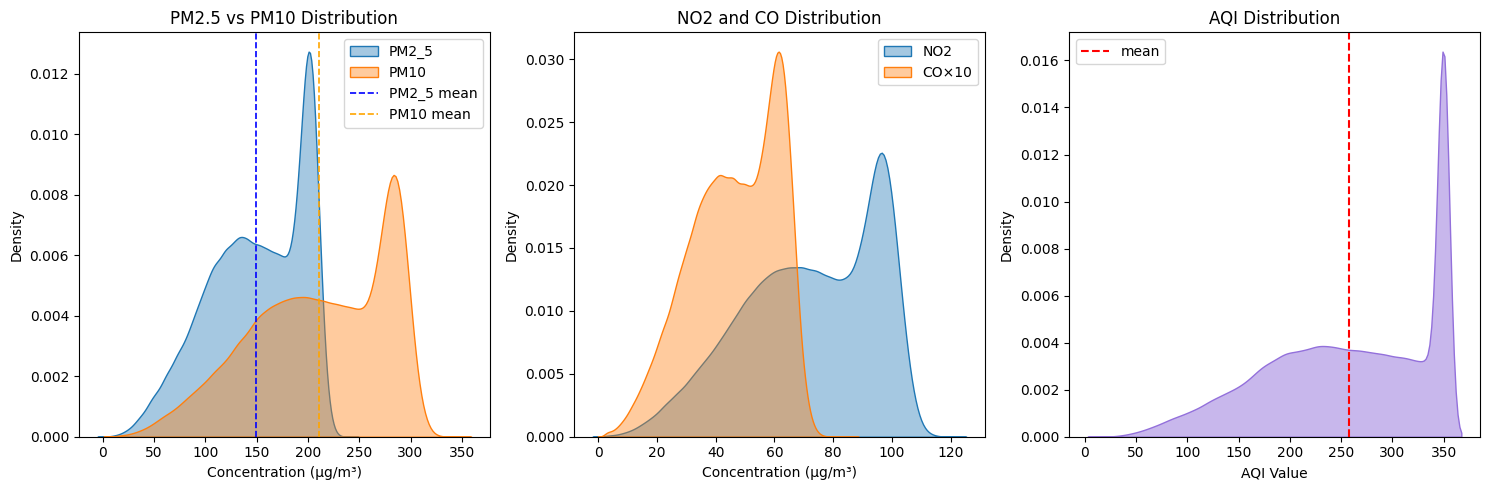

In [99]:
# DISTRIBUTION OVERLAY

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(pollution_pd['PM2_5'], label='PM2_5', fill=True, alpha=0.4)
sns.kdeplot(pollution_pd['PM10'],  label='PM10',  fill=True, alpha=0.4)
plt.axvline(pollution_pd['PM2_5'].mean(), color='blue', ls='--', lw=1.2, label='PM2_5 mean')
plt.axvline(pollution_pd['PM10'].mean(),  color='orange', ls='--', lw=1.2, label='PM10 mean')
plt.title("PM2.5 vs PM10 Distribution")
plt.xlabel("Concentration (µg/m³)") 
plt.ylabel("Density")
plt.legend()

plt.subplot(1, 3, 2)
sns.kdeplot(pollution_pd['NO2'], label='NO2', fill=True, alpha=0.4)
sns.kdeplot(pollution_pd['CO'] * 10, label='CO×10', fill=True, alpha=0.4)
plt.title("NO2 and CO Distribution")
plt.xlabel("Concentration (µg/m³)")  
plt.ylabel("Density")
plt.legend()

plt.subplot(1, 3, 3)
sns.kdeplot(pollution_pd['AQI'], fill=True, color='mediumpurple', alpha=0.5)
plt.axvline(pollution_pd['AQI'].mean(), color='red', ls='--', lw=1.5, label='mean')
plt.title("AQI Distribution")
plt.xlabel("AQI Value")              
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

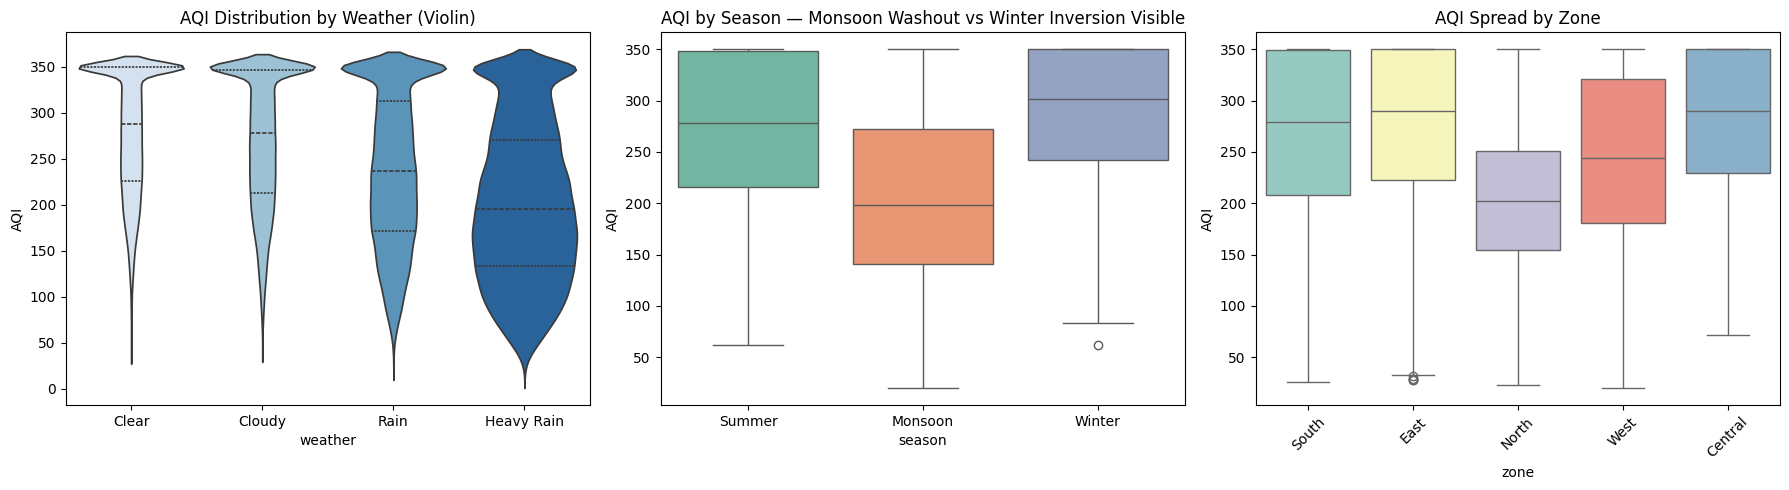

In [100]:
# CATEGORY ANALYSIS

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.violinplot(x='weather', y='AQI', data=pollution_pd,
               palette='Blues', inner='quartile')
plt.title("AQI Distribution by Weather (Violin)")

plt.subplot(1,3,2)
sns.boxplot(x='season', y='AQI', data=pollution_pd,
            palette='Set2',
            order=['Summer','Monsoon','Winter'])
plt.title("AQI by Season — Monsoon Washout vs Winter Inversion Visible")

plt.subplot(1,3,3)
sns.boxplot(x='zone', y='AQI', data=pollution_pd, palette='Set3')
plt.title("AQI Spread by Zone")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

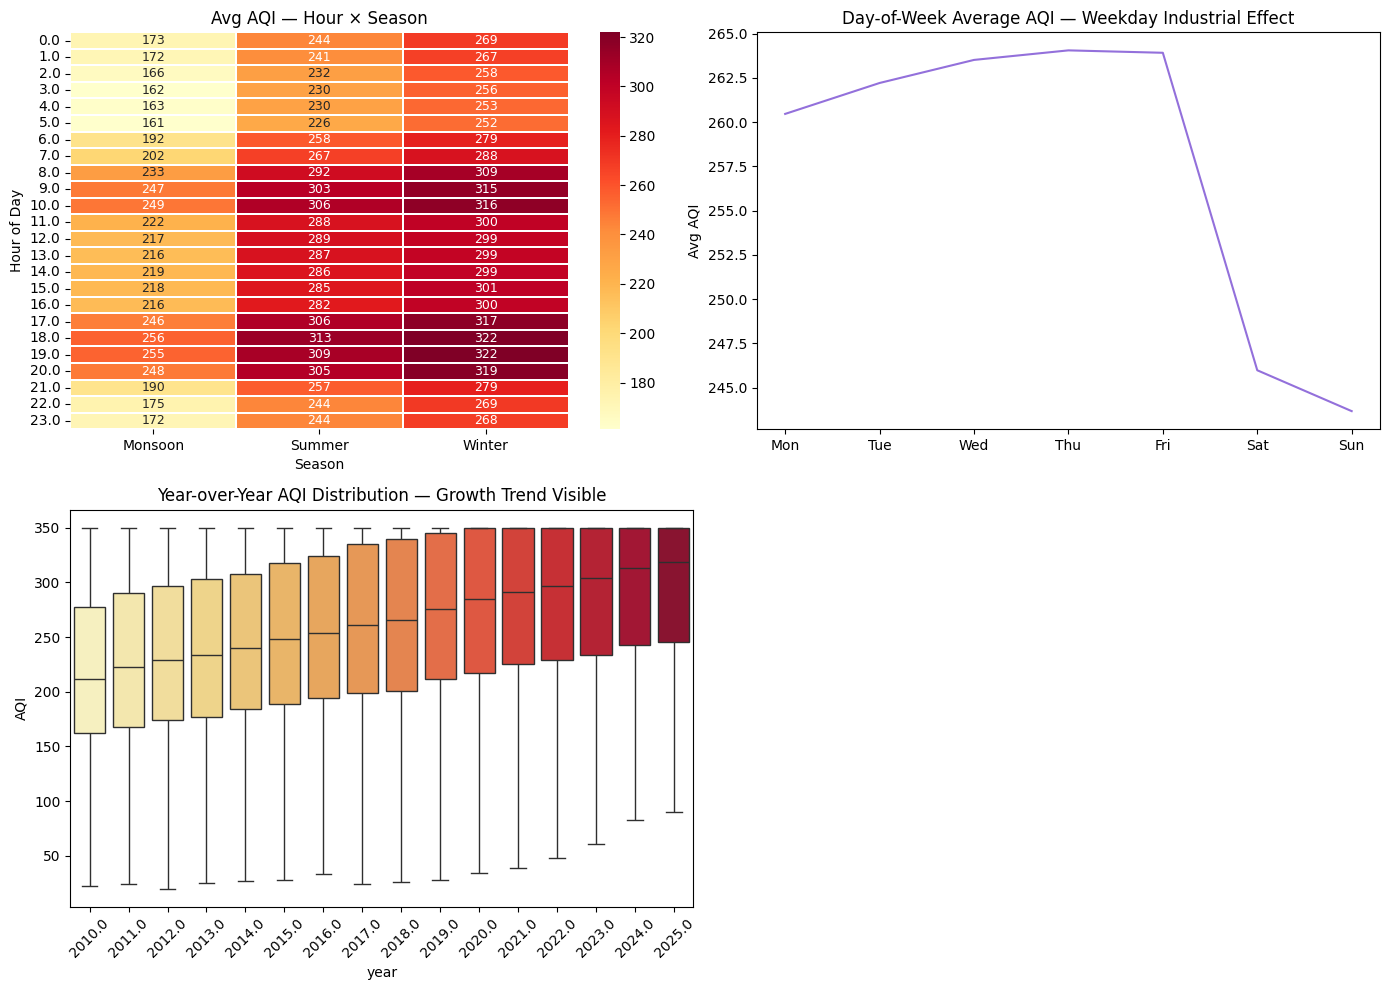

In [101]:
# TIME SERIES ANALYSIS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pivot_hs = pollution_pd.pivot_table(
    values='AQI', index='hour', columns='season', aggfunc='mean'
)
sns.heatmap(pivot_hs, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, annot_kws={'size': 9}, ax=axes[0,0])
axes[0,0].set_title("Avg AQI — Hour × Season")
axes[0,0].set_xlabel("Season")
axes[0,0].set_ylabel("Hour of Day")

daily_p = pollution_pd.groupby('dayofweek')['AQI'].mean()
daily_p.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_p.plot(color='mediumpurple', ax=axes[0,1])
axes[0,1].set_title("Day-of-Week Average AQI — Weekday Industrial Effect")
axes[0,1].set_ylabel("Avg AQI")
axes[0,1].tick_params(axis='x', rotation=0)

sns.boxplot(x='year', y='AQI', data=pollution_pd,
            palette='YlOrRd', showfliers=False, ax=axes[1,0])
axes[1,0].set_title("Year-over-Year AQI Distribution — Growth Trend Visible")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].axis('off')
plt.tight_layout()
plt.show()

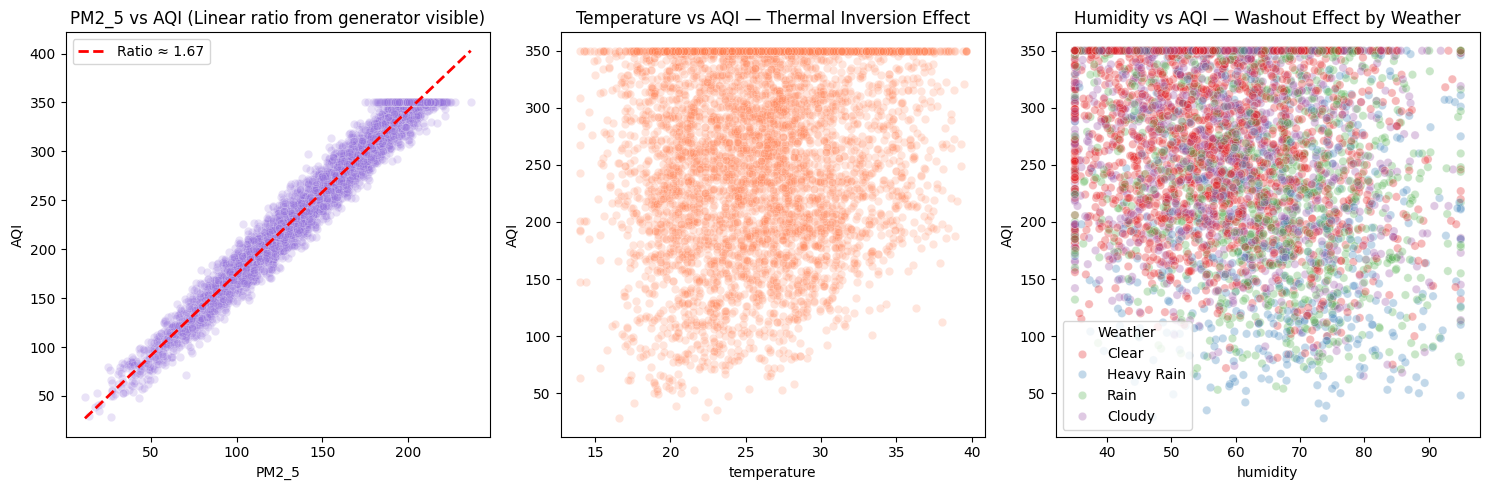

In [102]:
# RELATIONSHIP ANALYSIS

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sample_p = pollution_pd.sample(min(5000, len(pollution_pd)), random_state=42)
sns.scatterplot(x='PM2_5', y='AQI', data=sample_p, alpha=0.2, color='mediumpurple')
z_p = np.polyfit(sample_p['PM2_5'], sample_p['AQI'], 1)
p_p = np.poly1d(z_p)
x_p = np.linspace(sample_p['PM2_5'].min(), sample_p['PM2_5'].max(), 100)
plt.plot(x_p, p_p(x_p), 'r--', lw=2, label=f'Ratio ≈ {z_p[0]:.2f}')
plt.title("PM2_5 vs AQI (Linear ratio from generator visible)")
plt.legend()

plt.subplot(1,3,2)
sns.scatterplot(x='temperature', y='AQI', data=sample_p, alpha=0.2, color='coral')
plt.title("Temperature vs AQI — Thermal Inversion Effect")

plt.subplot(1,3,3)
sns.scatterplot(x='humidity', y='AQI', hue='weather',
                data=sample_p, alpha=0.3, palette='Set1')
plt.title("Humidity vs AQI — Washout Effect by Weather")
plt.legend(title='Weather')
plt.tight_layout()
plt.show()

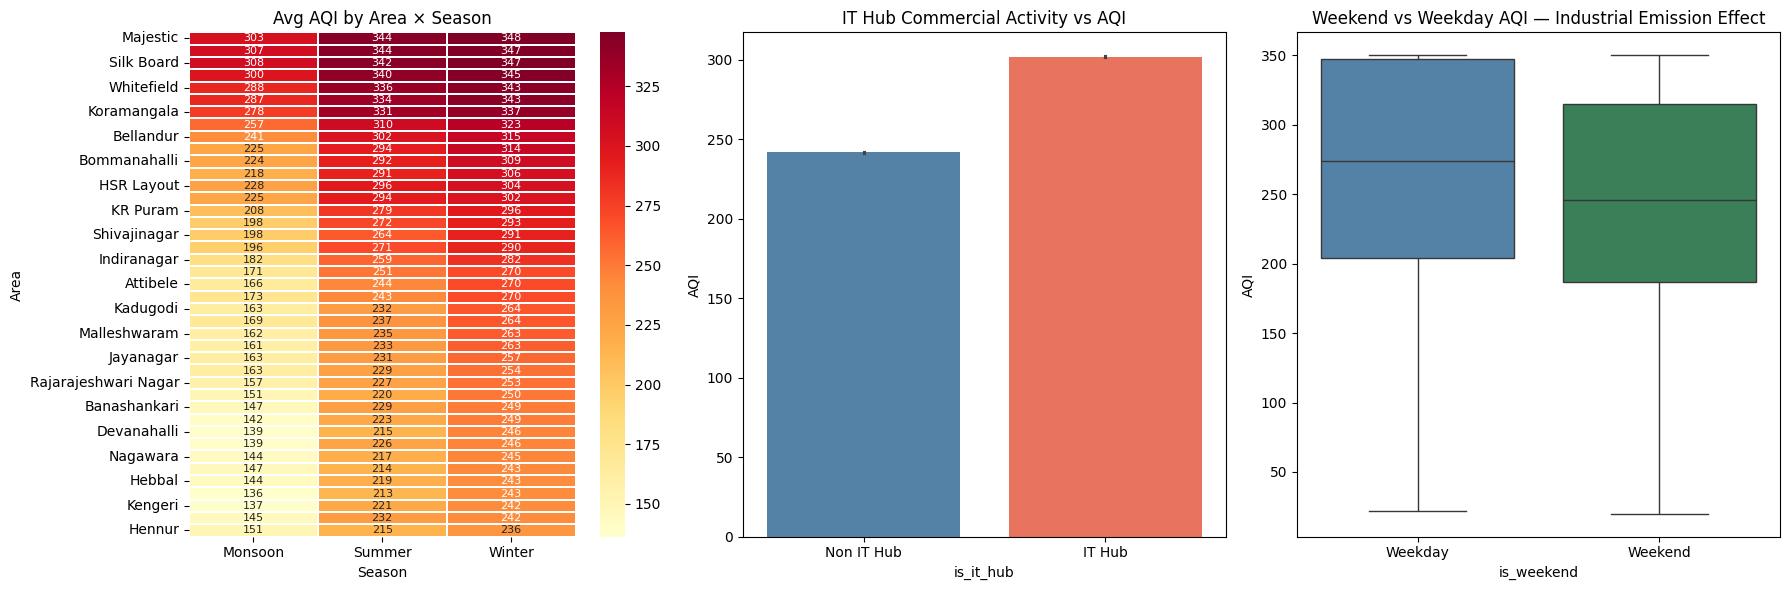

In [103]:
# ADVANCED INSIGHTS

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pivot_as = pollution_pd.pivot_table(
    values='AQI', index='area', columns='season', aggfunc='mean'
).sort_values('Winter', ascending=False)

sns.heatmap(pivot_as, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, annot_kws={'size': 8}, ax=axes[0])
axes[0].set_title("Avg AQI by Area × Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Area")

sns.barplot(x='is_it_hub', y='AQI', data=pollution_pd,
            palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title("IT Hub Commercial Activity vs AQI")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non IT Hub', 'IT Hub'])

sns.boxplot(x='is_weekend', y='AQI', data=pollution_pd,
            palette=['steelblue','seagreen'], ax=axes[2])
axes[2].set_title("Weekend vs Weekday AQI — Industrial Emission Effect")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Weekday', 'Weekend'])

plt.tight_layout()
plt.show()

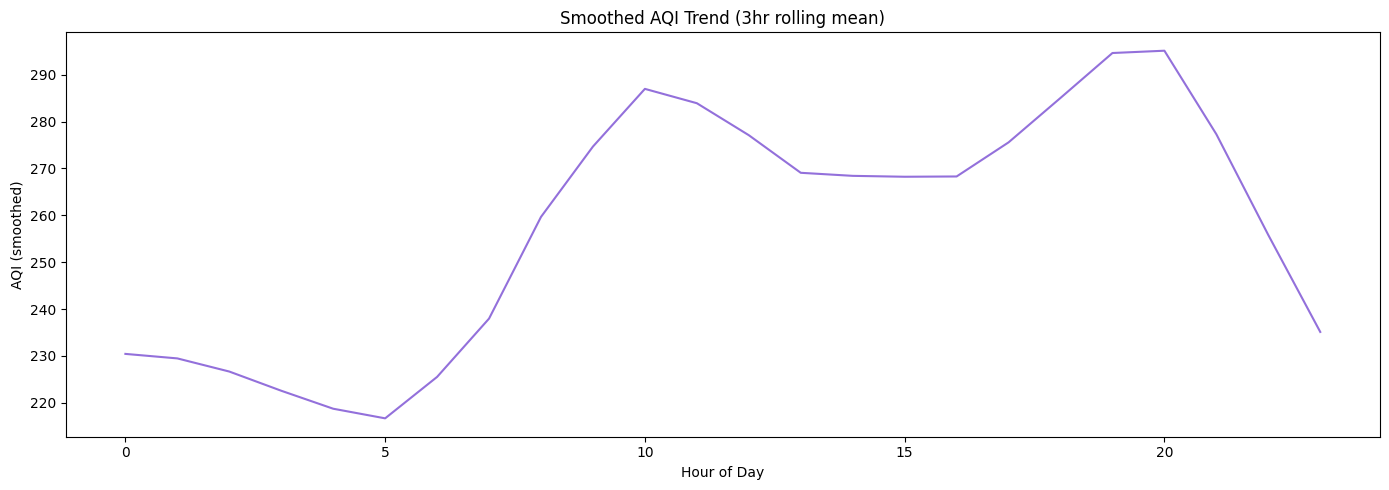

In [104]:
# TREND SMOOTHING

hourly_aqi = (pollution_pd.groupby('hour')['AQI'].mean()
              .rolling(3, min_periods=1).mean())
hourly_aqi.plot(figsize=(14, 5), color='mediumpurple')
plt.title("Smoothed AQI Trend (3hr rolling mean)")
plt.ylabel("AQI (smoothed)")
plt.xlabel("Hour of Day")
plt.tight_layout()
plt.show()

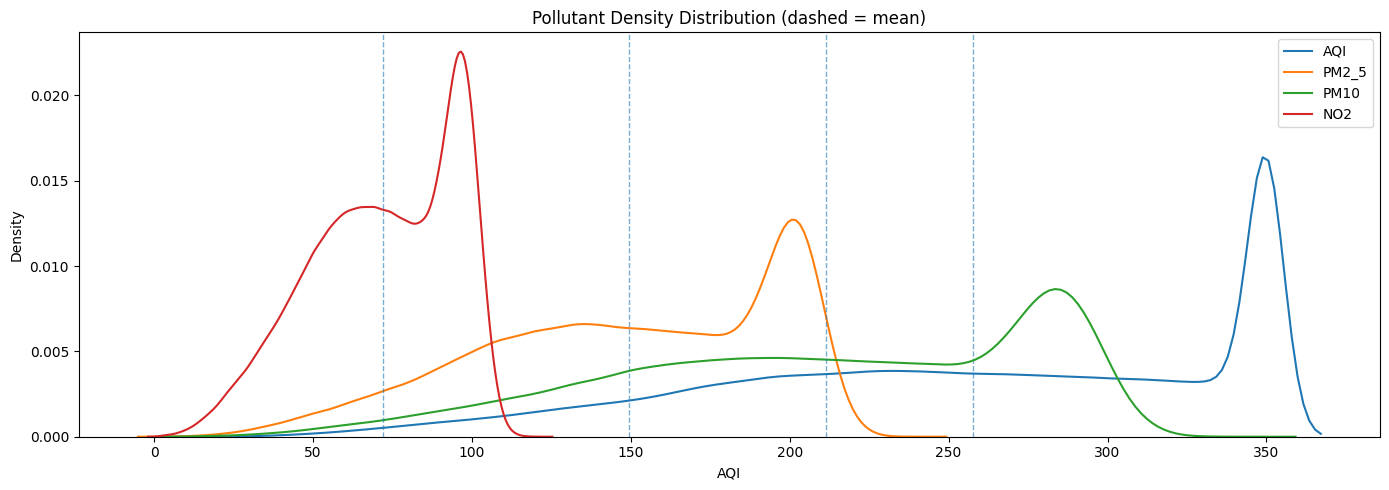

In [105]:
# DENSITY PLOT

plt.figure(figsize=(14, 5))
cols_density = ['AQI','PM2_5','PM10','NO2']
for feat_col in cols_density:
    sns.kdeplot(pollution_pd[feat_col], label=feat_col)
    plt.axvline(pollution_pd[feat_col].mean(), ls='--', lw=1, alpha=0.6)
plt.legend()
plt.title("Pollutant Density Distribution (dashed = mean)")
plt.tight_layout()
plt.show()

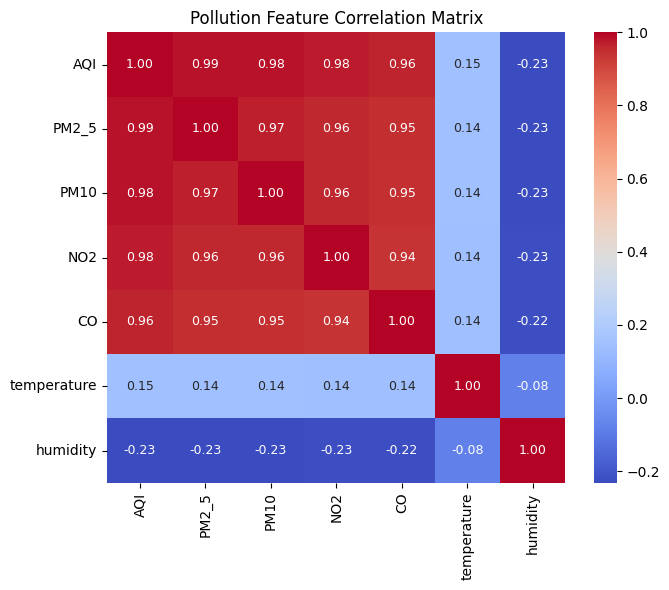

In [106]:
# CORRELATION HEATMAP

plt.figure(figsize=(7, 6))
sns.heatmap(
    pollution_pd[['AQI','PM2_5','PM10','NO2','CO','temperature','humidity']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 9}
)
plt.title("Pollution Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [107]:
# ── Save as PARQUET ─────────────────────────────
pollution_clean_parquet = "clean_data/pollution_clean.parquet"

pollution_clean.write \
    .mode("overwrite") \
    .parquet(pollution_clean_parquet)

# ── Save as CSV ─────────────────────────────────
pollution_clean_csv = "clean_data/pollution_clean_csv"

pollution_clean.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(pollution_clean_csv)

part_file = [f for f in os.listdir(pollution_clean_csv) if f.startswith("part-")][0]
shutil.move(
    os.path.join(pollution_clean_csv, part_file),
    "clean_data/pollution_clean.csv"
)

shutil.rmtree(pollution_clean_csv)

print(f"Pollution Parquet saved → {pollution_clean_parquet}")
print(f"Pollution CSV saved → clean_data/pollution_clean.csv")
print(f"Shape: ({pollution_clean.count()}, {len(pollution_clean.columns)})")

# Release cache after save
pollution.unpersist()

Pollution Parquet saved → clean_data/pollution_clean.parquet
Pollution CSV saved → clean_data/pollution_clean.csv
Shape: (500000, 19)


DataFrame[timestamp: timestamp, area: string, zone: string, AQI: int, PM2_5: double, PM10: double, NO2: double, CO: double, weather: string, temperature: double, humidity: double, is_weekend: int, is_it_hub: int, season: string, hour: int, day: int, dayofweek: int, month: int, year: int]

**Final Summary**

In [109]:
# Define datasets list first
datasets = [
    ("Traffic", traffic_clean, "clean_data/traffic_clean.parquet", "clean_data/traffic_clean.csv"),
    ("Energy", energy_clean, "clean_data/energy_clean.parquet", "clean_data/energy_clean.csv"),
    ("Pollution", pollution_clean, "clean_data/pollution_clean.parquet", "clean_data/pollution_clean.csv"),
]

for name, df, parquet_path, csv_path in datasets:
    # Row and column count
    rows = df.count()
    cols = len(df.columns)

    # ── Size formatter ─────────────────────────
    def fmt_size(size_bytes):
        if size_bytes >= 1024 * 1024:
            return f"{size_bytes / (1024 * 1024):.1f} MB"
        return f"{size_bytes / 1024:.0f} KB"

    # ── Parquet Size ───────────────────────────
    parquet_size = 0
    if os.path.isdir(parquet_path):
        for dirpath, _, filenames in os.walk(parquet_path):
            for f in filenames:
                if f.startswith("part-"):
                    parquet_size += os.path.getsize(
                        os.path.join(dirpath, f)
                    )

    # ── CSV Size ───────────────────────────────
    csv_size = 0
    if os.path.isfile(csv_path):
        csv_size = os.path.getsize(csv_path)

    print(f"\n{name}")
    print(f"  Rows: {rows:,}")
    print(f"  Cols: {cols}")
    print(f"  Parquet → {parquet_path}")
    print(f"     Size: {fmt_size(parquet_size)}")
    print(f"  CSV → {csv_path}")
    print(f"     Size: {fmt_size(csv_size)}")

print("\n" + "="*55)


Traffic
  Rows: 499,999
  Cols: 20
  Parquet → clean_data/traffic_clean.parquet
     Size: 8.9 MB
  CSV → clean_data/traffic_clean.csv
     Size: 73.8 MB

Energy
  Rows: 500,000
  Cols: 19
  Parquet → clean_data/energy_clean.parquet
     Size: 10.5 MB
  CSV → clean_data/energy_clean.csv
     Size: 65.7 MB

Pollution
  Rows: 500,000
  Cols: 19
  Parquet → clean_data/pollution_clean.parquet
     Size: 11.0 MB
  CSV → clean_data/pollution_clean.csv
     Size: 62.9 MB



In [110]:
spark.stop()
print("Spark session stopped")

Spark session stopped
